<a href="https://colab.research.google.com/github/refimaulan06/Delhivery-Analysis/blob/main/Delhivery_Analysis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 3.0 MB/s eta 0:00:00


# Eksplorasi Data Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
import matplotlib.pyplot as mtp
import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data
delhivery_data = pd.read_csv('/content/delhivery_data.csv')

In [ ]:
#Cek dimensi data frame
delhivery_data.shape

(144867, 24)

In [ ]:
# cek detail informasi data
delhivery_data.head(24)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333


# Pengecekan Missing Value

In [ ]:
# lihat isi data kita
delhivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

Terdapat 2 Kolom yang berisi NaN atau Memiliki Missing Value,kita akan investigasi lebih lanjut

In [ ]:
# hitung jumlah missing value disetiap kolom
delhivery_data.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
# hitung proporsi missing value disetiap kolom

(delhivery_data.isna().sum() / delhivery_data.shape[0]) * 100

,0
data,0.000000
trip_creation_time,0.000000
route_schedule_uuid,0.000000
route_type,0.000000
trip_uuid,0.000000
source_center,0.000000
source_name,0.202254
destination_center,0.000000
destination_name,0.180165
od_start_time,0.000000


In [ ]:
# lihat isi typename
delhivery_data.groupby(['data']).size()

,0
data,
test,40009
training,104858


In [ ]:
# lihat isi typename
delhivery_data.groupby(['trip_creation_time', 'trip_uuid']).size()

,,0
trip_creation_time,trip_uuid,
2018-09-12 00:00:16.535741,trip-153671041653548748,39
2018-09-12 00:00:22.886430,trip-153671042288605164,9
2018-09-12 00:00:33.691250,trip-153671043369099517,89
2018-09-12 00:01:00.113710,trip-153671046011330457,2
2018-09-12 00:02:09.740725,trip-153671052974046625,7
...,...,...
2018-10-03 23:55:56.258533,trip-153861095625827784,7
2018-10-03 23:57:23.863155,trip-153861104386292051,2
2018-10-03 23:57:44.429324,trip-153861106442901555,6


In [ ]:
# lihat isi typename
delhivery_data.groupby(['route_schedule_uuid', 'route_type']).size()

,,0
route_schedule_uuid,route_type,
thanos::sroute:0007affd-fd01-4cf0-8a4f-90419df059f7,Carting,65
thanos::sroute:00435307-de7f-4439-bd6a-5a2a9a3cd8bf,Carting,36
thanos::sroute:00a74fab-a3ac-44df-b83a-cbf181b4cd94,FTL,12
thanos::sroute:00b294b8-d2c3-4bca-a3be-684f46278bdd,Carting,139
thanos::sroute:01164881-301e-45f8-bacd-ee21c37f1cc4,FTL,87
...,...,...
thanos::sroute:ff52ef7a-4d0d-4063-9bfe-cc211728881b,FTL,80
thanos::sroute:ff6d6662-580b-43c3-810c-ba3027000f79,Carting,271
thanos::sroute:ff9b1c17-a70d-412a-acd1-5ab51d892d22,FTL,48


In [ ]:
# lihat isi typename
delhivery_data.groupby(['source_center', 'source_name']).size()

,,0
source_center,source_name,
IND000000AAL,Pune_PC (Maharashtra),37
IND000000AAQ,Barasat_KrshnNgr_D (West Bengal),4
IND000000AAS,Bongaigaon_Chpaguri_D (Assam),18
IND000000AAZ,Buldhana_Thsil3PL_D (Maharashtra),6
IND000000ABA,Cochin_Chtrpuza_D (Kerala),13
...,...,...
IND854105AAB,Katihar_Central_D_2 (Bihar),35
IND854311AAA,Araria_Wardn13_D (Bihar),22
IND854326AAB,Purnia_Central_H_2 (Bihar),1053


In [ ]:
# lihat isi typename
delhivery_data.groupby(['destination_center', 'destination_name']).size()

,,0
destination_center,destination_name,
IND000000AAL,Pune_PC (Maharashtra),37
IND000000AAS,Bongaigaon_Chpaguri_D (Assam),24
IND000000AAZ,Buldhana_Thsil3PL_D (Maharashtra),6
IND000000ABA,Cochin_Chtrpuza_D (Kerala),47
IND000000ABD,Pallakad_ChndrNgr_D (Kerala),26
...,...,...
IND854105AAB,Katihar_Central_D_2 (Bihar),22
IND854311AAA,Araria_Wardn13_D (Bihar),45
IND854326AAB,Purnia_Central_H_2 (Bihar),394


In [ ]:
# lihat isi typename
delhivery_data.groupby(['od_start_time', 'od_end_time']).size()

,,0
od_start_time,od_end_time,
2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,21
2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,6
2018-09-12 00:00:33.691250,2018-09-14 03:40:17.106733,77
2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,2
2018-09-12 00:02:09.740725,2018-09-12 02:34:10.515593,3
...,...,...
2018-10-05 04:41:17.249833,2018-10-05 09:36:36.842982,5
2018-10-05 06:43:18.986348,2018-10-05 13:43:34.378032,10
2018-10-05 08:35:15.664489,2018-10-05 19:10:48.347039,8


In [ ]:
# lihat isi typename
delhivery_data.groupby(['start_scan_to_end_scan']).size()

,0
start_scan_to_end_scan,
20.0,2
21.0,2
22.0,1
23.0,3
25.0,2
...,...
4207.0,75
4239.0,60
4440.0,77


In [ ]:
# lihat isi typename
delhivery_data.groupby(['is_cutoff']).size()

,0
is_cutoff,
False,26118
True,118749


In [ ]:
# lihat isi typename
delhivery_data.groupby(['cutoff_factor', 'cutoff_timestamp']).size()

cutoff_factor  cutoff_timestamp          
9              2018-09-12 00:10:27           1
               2018-09-12 00:22:12.931636    1
               2018-09-12 00:27:26           1
               2018-09-12 00:43:26           1
               2018-09-12 00:45:25           1
                                            ..
1848           2018-09-21 23:18:30           1
1870           2018-09-21 22:54:27           1
1892           2018-09-21 22:30:28           1
1914           2018-09-21 22:06:28           1
1927           2018-09-21 18:42:31           1
Length: 139422, dtype: int64

In [ ]:
# lihat isi typename
delhivery_data.groupby(['actual_distance_to_destination', 'actual_time']).size()

,,0
actual_distance_to_destination,actual_time,
9.000045,44.0,1
9.000055,37.0,1
9.000113,30.0,1
9.000221,72.0,1
9.000267,16.0,1
...,...,...
1853.249750,3508.0,1
1876.975233,3532.0,1
1901.686641,3556.0,1


In [ ]:
# lihat isi typename
delhivery_data.groupby(['osrm_time', 'osrm_distance']).size()

osrm_time  osrm_distance
6.0        9.0082           1
           9.0510           1
           9.0988           1
           9.1054           1
           9.1217           1
                           ..
1629.0     2245.3849        1
1650.0     2275.5970        1
1664.0     2294.8983        1
1682.0     2319.9344        1
1686.0     2326.1991        1
Length: 142677, dtype: int64

In [ ]:
# lihat isi typename
delhivery_data.groupby(['factor']).size()

,0
factor,
0.144000,1
0.203125,1
0.247788,1
0.250000,2
0.260870,1
...,...
69.800000,1
70.000000,1
72.133333,1


In [ ]:
# lihat isi typename
delhivery_data.groupby(['segment_actual_time', 'segment_osrm_time']).size()

,,0
segment_actual_time,segment_osrm_time,
-244.0,30.0,1
-211.0,9.0,1
-74.0,15.0,1
-58.0,22.0,1
-51.0,21.0,1
...,...,...
2464.0,996.0,1
2491.0,73.0,1
2541.0,211.0,1


In [ ]:
# lihat isi typename
delhivery_data.groupby(['segment_osrm_distance', 'segment_factor']).size()

,,0
segment_osrm_distance,segment_factor,
0.0000,-1.000000,1536
0.0001,-1.000000,1
0.0006,-1.000000,1
0.0014,-1.000000,1
0.0027,-1.000000,1
...,...,...
995.1636,2.275441,1
1367.0419,2.473896,1
1367.5928,2.358074,1


In [ ]:
# filter dataframe untuk menampilkan baris yang nilainya null di salah satu kolom
delhivery_data[delhivery_data['source_name'].isna()].head(10)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
112,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 14:09:19,22.783440,48.0,34.0,37.7749,1.411765,48.0,34.0,37.7749,1.411765
113,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 13:19:23,46.071250,98.0,41.0,56.3575,2.390244,49.0,33.0,34.1661,1.484848
114,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 12:49:33,67.714993,127.0,58.0,80.4811,2.189655,29.0,17.0,24.1236,1.705882
115,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 12:21:18,88.149642,156.0,73.0,101.2556,2.136986,28.0,14.0,20.7746,2.000000
116,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 11:25:24,112.691981,212.0,92.0,127.9860,2.304348,55.0,18.0,26.7304,3.055556
117,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 10:31:22,132.128898,266.0,117.0,156.5566,2.273504,54.0,25.0,28.5706,2.160000
118,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 09:43:23,154.305625,314.0,138.0,186.5238,2.275362,47.0,21.0,29.9673,2.238095
119,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 09:07:27,178.611991,350.0,161.0,218.2945,2.173913,35.0,22.0,31.7707,1.590909
120,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 08:26:15,199.353179,391.0,176.0,234.8976,2.221591,41.0,20.0,22.9423,2.050000
121,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 08:05:22,208.029246,412.0,185.0,244.0840,2.227027,20.0,8.0,9.1864,2.500000


In [ ]:
  # filter dataframe untuk menampilkan baris yang nilainya null di kedua kolom sekaligus
delhivery_data[(delhivery_data['source_name'].isnull()) & (delhivery_data['destination_name'].isnull())].shape

(3, 24)

Kita Pisahkan Categorical Columns dan Numerical Columns

### Categorical Columns

In [ ]:
delhivery_data.describe(include=['object'])

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,cutoff_timestamp
count,144867,144867,144867,144867,144867,144867,144574,144867,144606,144867,144867,144867
unique,2,14817,1504,2,14817,1508,1498,1481,1468,26369,26369,93180
top,training,2018-09-28 05:23:15.359220,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153811219535896559,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-21 18:37:09.322207,2018-09-24 09:59:15.691618,2018-09-24 05:19:20
freq,104858,101,1812,99660,101,23347,23347,15192,15192,81,81,40


In [ ]:
cat_columns=delhivery_data.dtypes=='object'
category=list(cat_columns[cat_columns].index)
num_columns=delhivery_data.dtypes!='object'
numerical=list(num_columns[num_columns].index)

In [ ]:
category_data=delhivery_data[category]
category_data

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,cutoff_timestamp
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,2018-09-20 04:27:55
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,2018-09-20 04:17:55
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,2018-09-20 04:01:19.505586
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,2018-09-20 03:39:57
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,2018-09-20 03:33:55
...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,2018-09-20 21:57:20
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,2018-09-20 21:31:18
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,2018-09-20 21:11:18
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,2018-09-20 20:53:19


In [ ]:
for col in category_data.columns:
    print(col,':',category_data[col].nunique())

data : 2
trip_creation_time : 14817
route_schedule_uuid : 1504
route_type : 2
trip_uuid : 14817
source_center : 1508
source_name : 1498
destination_center : 1481
destination_name : 1468
od_start_time : 26369
od_end_time : 26369
cutoff_timestamp : 93180


### Numerical Columns

In [ ]:
numerical_data=delhivery_data[numerical]
numerical_data

,start_scan_to_end_scan,is_cutoff,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,86.0,True,9,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,86.0,True,18,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,86.0,True,27,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,86.0,True,36,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,86.0,False,39,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...
144862,427.0,True,45,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,427.0,True,54,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,427.0,True,63,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,427.0,True,72,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630


In [ ]:
for col in numerical_data.columns:
    print(col,':',numerical_data[col].nunique())

start_scan_to_end_scan : 1915
is_cutoff : 2
cutoff_factor : 501
actual_distance_to_destination : 144515
actual_time : 3182
osrm_time : 1531
osrm_distance : 138046
factor : 45641
segment_actual_time : 747
segment_osrm_time : 214
segment_osrm_distance : 113799
segment_factor : 5675


# Pembersihan Data

### Pengecekan Duplikat

In [ ]:
# mari kita lihat apakah terdapat duplikat di data kita
print(f"Jumlah data duplikat: {delhivery_data.duplicated().sum()}")

Jumlah data duplikat: 0


# Data Typos

### Delhivery Data

In [ ]:
delhivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
#Cek data typos disetiap kolom
typoDF2 = delhivery_data.select_dtypes(include=['object']).columns
for col in typoDF2:
  print(col)
  print(pd.DataFrame(delhivery_data[col].unique()))

data
          0
0  training
1      test
trip_creation_time
                                0
0      2018-09-20 02:35:36.476840
1      2018-09-23 06:42:06.021680
2      2018-09-14 15:42:46.437249
3      2018-09-13 20:44:19.424489
4      2018-09-29 22:21:45.149226
...                           ...
14812  2018-09-26 19:50:29.657378
14813  2018-09-14 18:45:34.164734
14814  2018-09-22 11:30:41.399439
14815  2018-09-17 11:35:28.838714
14816  2018-09-20 16:24:28.436231

[14817 rows x 1 columns]
route_schedule_uuid
                                                      0
0     thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...
1     thanos::sroute:ff52ef7a-4d0d-4063-9bfe-cc21172...
2     thanos::sroute:a16bfa03-3462-4bce-9c82-5784c7d...
3     thanos::sroute:76951383-1608-44e4-a284-46d92e8...
4     thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...
...                                                 ...
1499  thanos::sroute:4a59da37-95e1-45a3-9bbc-3ee4d69...
1500  thanos::sroute:629ad783-00c1-459

### Pengecekan Kolom Segment Actual Time

In [ ]:
# mari kita lihat isi dari kolom segment_actual_time
delhivery_data['segment_actual_time'].unique()

array([ 1.400e+01,  1.000e+01,  1.600e+01,  2.100e+01,  6.000e+00,
        1.500e+01,  2.800e+01,  2.600e+01,  3.800e+01,  3.700e+01,
        4.100e+01,  2.300e+01,  4.600e+01,  3.000e+01,  5.000e+01,
        9.300e+01,  6.200e+01,  4.900e+01,  2.700e+01,  3.500e+01,
        6.700e+01,  2.000e+01,  5.100e+01,  9.400e+01,  1.900e+01,
        1.200e+01,  1.800e+01,  1.100e+01,  2.000e+00,  1.300e+01,
        2.400e+01,  5.700e+01,  1.000e+00,  0.000e+00,  2.200e+01,
        2.500e+01,  4.500e+01,  8.000e+00,  3.600e+01,  4.200e+01,
        4.400e+01,  7.500e+01,  7.800e+01,  2.900e+01,  3.400e+01,
        3.200e+01,  6.000e+01,  4.300e+01,  7.900e+01,  4.000e+01,
        6.900e+01,  5.800e+01,  5.200e+01,  4.800e+01,  5.500e+01,
        5.400e+01,  4.700e+01,  9.000e+00,  8.700e+01,  1.700e+01,
        6.800e+01,  5.600e+01,  3.300e+01,  4.000e+00,  5.300e+01,
        2.000e+02,  6.500e+01,  3.100e+01,  8.800e+01,  7.000e+00,
        8.400e+01,  8.200e+01,  3.900e+01,  1.010e+02,  1.900e

In [ ]:
# pertama kita cek dulu ada berapa banyak kasus ini
print('Jumlah baris dengan data segment_actual_time negatif :', delhivery_data[delhivery_data['segment_actual_time'] < 0].shape[0])
print(f"% baris dengan data segment_actual_time negatif : {delhivery_data[delhivery_data['segment_actual_time'] < 0].shape[0]/delhivery_data.shape[0]:.2%}")

Jumlah baris dengan data segment_actual_time negatif : 21
% baris dengan data segment_actual_time negatif : 0.01%


In [ ]:
# mari kita ubah nilai negatif menjadi nilai positif
delhivery_data['segment_actual_time'] = delhivery_data['segment_actual_time'].abs()

In [ ]:
delhivery_data.head(15)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333


In [ ]:
# mari kita lihat isi dari kolom education
delhivery_data['segment_actual_time'].unique()

array([1.400e+01, 1.000e+01, 1.600e+01, 2.100e+01, 6.000e+00, 1.500e+01,
       2.800e+01, 2.600e+01, 3.800e+01, 3.700e+01, 4.100e+01, 2.300e+01,
       4.600e+01, 3.000e+01, 5.000e+01, 9.300e+01, 6.200e+01, 4.900e+01,
       2.700e+01, 3.500e+01, 6.700e+01, 2.000e+01, 5.100e+01, 9.400e+01,
       1.900e+01, 1.200e+01, 1.800e+01, 1.100e+01, 2.000e+00, 1.300e+01,
       2.400e+01, 5.700e+01, 1.000e+00, 0.000e+00, 2.200e+01, 2.500e+01,
       4.500e+01, 8.000e+00, 3.600e+01, 4.200e+01, 4.400e+01, 7.500e+01,
       7.800e+01, 2.900e+01, 3.400e+01, 3.200e+01, 6.000e+01, 4.300e+01,
       7.900e+01, 4.000e+01, 6.900e+01, 5.800e+01, 5.200e+01, 4.800e+01,
       5.500e+01, 5.400e+01, 4.700e+01, 9.000e+00, 8.700e+01, 1.700e+01,
       6.800e+01, 5.600e+01, 3.300e+01, 4.000e+00, 5.300e+01, 2.000e+02,
       6.500e+01, 3.100e+01, 8.800e+01, 7.000e+00, 8.400e+01, 8.200e+01,
       3.900e+01, 1.010e+02, 1.900e+02, 2.020e+02, 9.700e+01, 8.600e+01,
       2.910e+02, 1.620e+02, 4.310e+02, 1.060e+02, 

Terlihat Sudah Tidak Ada Angka Negatif Lagi

In [ ]:
delhivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

### Pengecekan Kolom segment_osrm_distance

In [ ]:
# mari kita lihat isi dari kolom segment_osrm_distance
delhivery_data['segment_osrm_distance'].unique()

array([11.9653,  9.759 , 10.8152, ..., 20.7053, 18.8885,  8.8088])

In [ ]:
delhivery_data['segment_osrm_distance'].value_counts()

,count
segment_osrm_distance,
0.0000,1536
25.6081,8
22.6267,8
58.2708,7
26.6974,7
...,...
13.6619,1
0.7952,1
8.1647,1


In [ ]:
# Hitung nilai median dari kolom 'segment_osrm_distance'
median_distance = delhivery_data['segment_osrm_distance'].median()

# Ganti nilai 0 dengan median
delhivery_data['segment_osrm_distance'] = delhivery_data['segment_osrm_distance'].replace(0, median_distance)

In [ ]:
delhivery_data['segment_osrm_distance'].value_counts().sort_index().head()

,count
segment_osrm_distance,
0.0001,1
0.0006,1
0.0014,1
0.0027,1
0.0028,1


### Konversi object menjadi DateTime

In [ ]:
delhivery_data['trip_creation_time']=pd.to_datetime(delhivery_data['trip_creation_time'])
delhivery_data['od_start_time']=pd.to_datetime(delhivery_data['od_start_time'])
delhivery_data['od_end_time']=pd.to_datetime(delhivery_data['od_end_time'])
# data['cutoff_timestamp']=pd.to_datetime(data['cutoff_timestamp'])

In [ ]:
delhivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  object        
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  object        
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144574 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144606 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

In [ ]:
delhivery_data.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


# Imputasi/ Mengisi Missing Values

[]

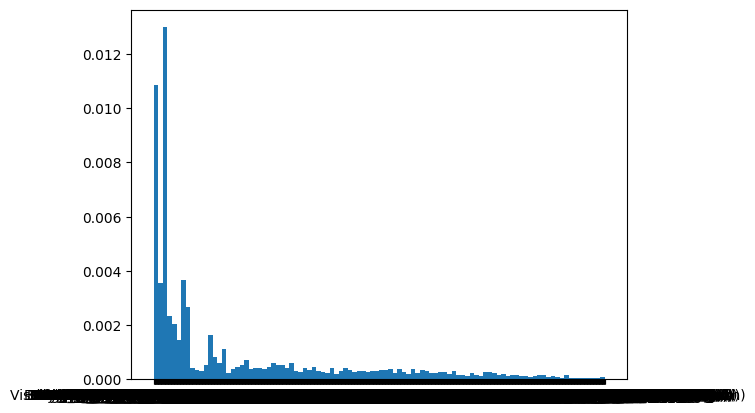

In [ ]:
# plot histogram source_name
plt.hist(delhivery_data['source_name'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

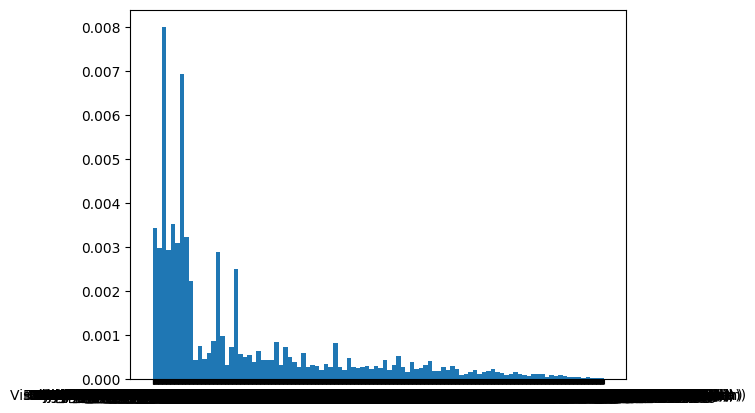

In [ ]:
# plot histogram destination_name
plt.hist(delhivery_data['destination_name'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

In [ ]:
# simpan nilai mode kedua kolom secara terpisah
mode_source_name = delhivery_data['source_name'].mode()[0]
mode_destination_name = delhivery_data['destination_name'].mode()[0]
print(f"Nilai mode untuk kolom source_name : {mode_source_name}")
print(f"Nilai mode untuk kolom destination_name : {mode_destination_name}")

Nilai mode untuk kolom source_name : Gurgaon_Bilaspur_HB (Haryana)
Nilai mode untuk kolom destination_name : Gurgaon_Bilaspur_HB (Haryana)


In [ ]:
# Ganti nilai yang hilang menggunakan mode/freequency imputer
def missing_to_df(data):
    total_missing_delhivery_data = data.isnull().sum().sort_values(ascending =False)
    percent_missing_delhivery_data = (data.isnull().sum()/len(data)*100).sort_values(ascending=False)
    missing_data_delhivery_data = pd.concat([total_missing_delhivery_data, percent_missing_delhivery_data], axis=1, keys=['Total', 'Percent'])
    return missing_data_delhivery_data

In [ ]:
missing_delhivery_data = missing_to_df(delhivery_data)
missing_delhivery_data[missing_delhivery_data['Total'] > 0]

,Total,Percent
source_name,293,0.202254
destination_name,261,0.180165


Dari source_name 0,20% nilai data hilang

Dari nama_tujuan 0,18 % nilai data hilang

In [ ]:
# categorical
cat_missing = ['source_name', 'destination_name']
freq_imputer = SimpleImputer(strategy = 'most_frequent')
for col in cat_missing:
    delhivery_data[col] = pd.DataFrame(freq_imputer.fit_transform(pd.DataFrame(delhivery_data[col])))

In [ ]:
missing_to_df(delhivery_data)

,Total,Percent
data,0,0.0
trip_creation_time,0,0.0
segment_osrm_distance,0,0.0
segment_osrm_time,0,0.0
segment_actual_time,0,0.0
factor,0,0.0
osrm_distance,0,0.0
osrm_time,0,0.0
actual_time,0,0.0
actual_distance_to_destination,0,0.0


# Cek Outliers

### Cek Delhivery Data

In [ ]:
delhivery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  object        
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  object        
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144867 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144867 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

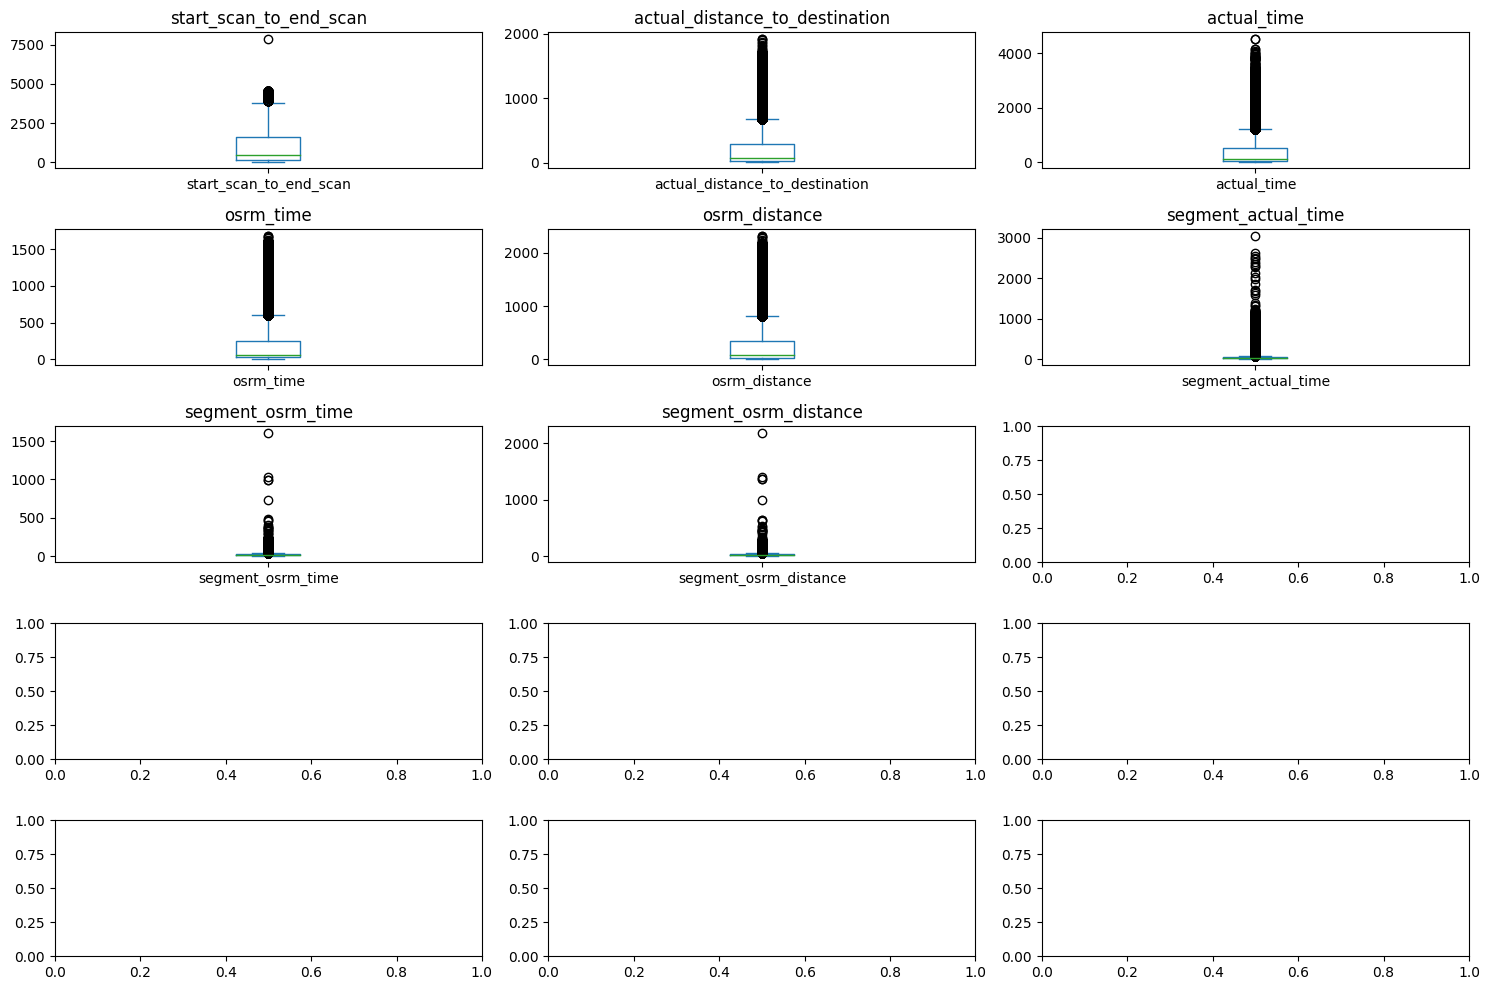

In [ ]:
#Cek outliers pada kolom data numerical menggunakan visualisasi boxplot
ratio_data = ['start_scan_to_end_scan', 'actual_distance_to_destination', 'actual_time',
              'osrm_time', 'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
               'segment_osrm_distance']

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 10))

# Iterasi melalui kolom-kolom yang akan diplot
for i, data in enumerate(ratio_data):
    # Menentukan subplot yang sesuai
    row = i // 3
    col = i % 3

    # Membuat boxplot dalam subplot
    delhivery_data[data].plot(kind='box', ax=axes[row, col])
    axes[row, col].set_title(data)

# Mengatur tata letak subplot
plt.tight_layout()

# Menampilkan gambar
plt.show()


In [ ]:
# membuatv fungsi cek outlier
def cek_outlier(nama_kolom, batas):
  Q1 = np.percentile(delhivery_data[nama_kolom], 25,
                     interpolation = 'midpoint')

  Q3 = np.percentile(delhivery_data[nama_kolom], 75,
                     interpolation = 'midpoint')

  IQR = Q3 - Q1

  if batas == 'upper_bound':
      bound = np.where(delhivery_data[nama_kolom] >= (Q3 + 1.5 * IQR))
  elif batas == 'lower_bound':
      bound = np.where(delhivery_data[nama_kolom] <= (Q1 - 1.5 * IQR))
  return list(bound[0])

In [ ]:
# Jumlah outliers kolom start_scan_to_end_scan
upper_start_scan_to_end_scan = cek_outlier('start_scan_to_end_scan','upper_bound')
lower_start_scan_to_end_scan = cek_outlier('start_scan_to_end_scan','lower_bound')
print(f"Jumlah total outlier kolom start_scan_to_end_scan : {len(upper_start_scan_to_end_scan) + len(lower_start_scan_to_end_scan)}")
#Jumlah outliers kolom actual_distance_to_destination
upper_actual_distance_to_destination = cek_outlier('actual_distance_to_destination','upper_bound')
lower_actual_distance_to_destination = cek_outlier('actual_distance_to_destination','lower_bound')
print(f"Jumlah total outlier kolom actual_distance_to_destination : {len(upper_actual_distance_to_destination) + len(lower_actual_distance_to_destination)}")
# Jumlah outliers kolom actual_time
upper_actual_time = cek_outlier('actual_time','upper_bound')
lower_actual_time = cek_outlier('actual_time','lower_bound')
print(f"Jumlah total outlier kolom actual_time : {len(upper_actual_time) + len(lower_actual_time)}")
#Jumlah outliers kolom osrm_time
upper_osrm_time = cek_outlier('osrm_time','upper_bound')
lower_osrm_time = cek_outlier('osrm_time','lower_bound')
print(f"Jumlah total outlier kolom osrm_time : {len(upper_osrm_time) + len(lower_osrm_time)}")
# Jumlah outliers kolom osrm_distance
upper_osrm_distance = cek_outlier('osrm_distance','upper_bound')
lower_osrm_distance = cek_outlier('osrm_distance','lower_bound')
print(f"Jumlah total outlier kolom osrm_distance : {len(upper_osrm_distance) + len(lower_osrm_distance)}")
# Jumlah outliers kolom segment_actual_time
upper_segment_actual_time = cek_outlier('segment_actual_time','upper_bound')
lower_segment_actual_time = cek_outlier('segment_actual_time','lower_bound')
print(f"Jumlah total outlier kolom segment_actual_time : {len(upper_segment_actual_time) + len(lower_segment_actual_time)}")
#Jumlah outliers kolom segment_osrm_time
upper_segment_osrm_time = cek_outlier('segment_osrm_time','upper_bound')
lower_segment_osrm_time = cek_outlier('segment_osrm_time','lower_bound')
print(f"Jumlah total outlier kolom segment_osrm_time : {len(upper_segment_osrm_time) + len(lower_segment_osrm_time)}")
# Jumlah outliers kolom segment_osrm_distance
upper_segment_osrm_distance = cek_outlier('segment_osrm_distance','upper_bound')
lower_segment_osrm_distance = cek_outlier('segment_osrm_distance','lower_bound')
print(f"Jumlah total outlier kolom segment_osrm_distance : {len(upper_segment_osrm_distance) + len(lower_segment_osrm_distance)}")

Jumlah total outlier kolom start_scan_to_end_scan : 373
Jumlah total outlier kolom actual_distance_to_destination : 17992
Jumlah total outlier kolom actual_time : 16649
Jumlah total outlier kolom osrm_time : 17621
Jumlah total outlier kolom osrm_distance : 17816
Jumlah total outlier kolom segment_actual_time : 9586
Jumlah total outlier kolom segment_osrm_time : 6378
Jumlah total outlier kolom segment_osrm_distance : 4415


# Handling Outliers (IQR)

### Delhivery Data 2

In [ ]:
delhivery_data2 =delhivery_data.copy()

In [ ]:
# Load data
delhivery_data2_cleaned = pd.read_csv('/content/delhivery_data2_cleaned.csv')

### Membangun beberapa fitur untuk mempersiapkan data untuk analisis aktual.



In [ ]:
delhivery_data2_cleaned[['destination','dest_state']] = delhivery_data2_cleaned['destination_name'].str.split('(', n=1, expand=True)
delhivery_data2_cleaned['dest_state'] = delhivery_data2_cleaned['dest_state'].str.rstrip(')')
delhivery_data2_cleaned[['dest_City','dest_place','dest_code']] = delhivery_data2_cleaned['destination'].str.split('_', n=2, expand=True)
delhivery_data2_cleaned[['source','source_state']] = delhivery_data2_cleaned['source_name'].str.split('(', n=1, expand=True)
delhivery_data2_cleaned['source_state'] = delhivery_data2_cleaned['source_state'].str.rstrip(')')
delhivery_data2_cleaned[['source_City','source_place','source_code']] = delhivery_data2_cleaned['source'].str.split('_', n=2, expand=True)

In [ ]:
delhivery_data2_cleaned['trip_creation_time']=pd.to_datetime(delhivery_data2_cleaned['trip_creation_time'])
delhivery_data2_cleaned['od_start_time']=pd.to_datetime(delhivery_data2_cleaned['od_start_time'])
delhivery_data2_cleaned['od_end_time']=pd.to_datetime(delhivery_data2_cleaned['od_end_time'])

In [ ]:
delhivery_data2_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 38 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Unnamed: 0                      144867 non-null  int64         
 1   data                            144867 non-null  object        
 2   trip_creation_time              144867 non-null  datetime64[ns]
 3   route_schedule_uuid             144867 non-null  object        
 4   route_type                      144867 non-null  object        
 5   trip_uuid                       144867 non-null  object        
 6   source_center                   144867 non-null  object        
 7   source_name                     144867 non-null  object        
 8   destination_center              144867 non-null  object        
 9   destination_name                144867 non-null  object        
 10  od_start_time                   144867 non-null  datetim

In [ ]:
# Imputasi mode untuk kolom numerik
mode_dest_place = delhivery_data2_cleaned['dest_place'].mode()[0]
mode_dest_code = delhivery_data2_cleaned['dest_code'].mode()[0]
mode_source_state = delhivery_data2_cleaned['source_state'].mode()[0]
mode_source_City = delhivery_data2_cleaned['source_City'].mode()[0]
mode_source_place = delhivery_data2_cleaned['source_place'].mode()[0]
mode_source_code = delhivery_data2_cleaned['source_code'].mode()[0]

# Terapkan imputasi mode
delhivery_data2_cleaned['dest_place'] = delhivery_data2_cleaned['dest_place'].fillna(mode_dest_place)
delhivery_data2_cleaned['dest_code'] = delhivery_data2_cleaned['dest_code'].fillna(mode_dest_code)
delhivery_data2_cleaned['source_state'] = delhivery_data2_cleaned['source_state'].fillna(mode_source_state)
delhivery_data2_cleaned['source_City'] = delhivery_data2_cleaned['source_City'].fillna(mode_source_City)
delhivery_data2_cleaned['source_place'] = delhivery_data2_cleaned['source_place'].fillna(mode_source_place)
delhivery_data2_cleaned['source_code'] = delhivery_data2_cleaned['source_code'].fillna(mode_source_code)

In [ ]:
delhivery_data2_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 38 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Unnamed: 0                      144867 non-null  int64         
 1   data                            144867 non-null  object        
 2   trip_creation_time              144867 non-null  datetime64[ns]
 3   route_schedule_uuid             144867 non-null  object        
 4   route_type                      144867 non-null  object        
 5   trip_uuid                       144867 non-null  object        
 6   source_center                   144867 non-null  object        
 7   source_name                     144867 non-null  object        
 8   destination_center              144867 non-null  object        
 9   destination_name                144867 non-null  object        
 10  od_start_time                   144867 non-null  datetim

In [ ]:
delhivery_data2_cleaned['trip_creation_year'] =delhivery_data2_cleaned['trip_creation_time'].dt.year
delhivery_data2_cleaned['trip_creation_month'] =delhivery_data2_cleaned['trip_creation_time'].dt.month_name()
delhivery_data2_cleaned['trip_creation_day'] =delhivery_data2_cleaned['trip_creation_time'].dt.day
delhivery_data2_cleaned

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,Bilaspur,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20
144863,144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,Bilaspur,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20
144864,144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,Bilaspur,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20
144865,144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,Bilaspur,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20


In [ ]:
delhivery_data2_cleaned_new = pd.get_dummies(delhivery_data2_cleaned, columns=["route_type"])
delhivery_data2_cleaned_new

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day,route_type_Carting,route_type_FTL
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,True,False
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,True,False
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,True,False
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,True,False
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,True,False
144863,144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,True,False
144864,144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,True,False
144865,144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,True,False


In [ ]:
delhivery_data2_cleaned['weekday'] = delhivery_data2_cleaned['trip_creation_time'].dt.day_name()
delhivery_data2_cleaned

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day,weekday
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,Thursday
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,Thursday
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,Thursday
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,Thursday
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,Thursday
144863,144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,Thursday
144864,144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,Thursday
144865,144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,HB,Sonipat_Kundli_H,Haryana,Sonipat,Kundli,H,2018,September,20,Thursday


In [ ]:
x=delhivery_data2_cleaned['weekday'].value_counts().to_frame('count').reset_index()
x

,weekday,count
0,Wednesday,26732
1,Thursday,20481
2,Friday,20242
3,Tuesday,19961
4,Saturday,19936
5,Monday,19645
6,Sunday,17870


### Label Encoding

In [ ]:
  cat_columns = ['start_scan_to_end_scan', 'actual_distance_to_destination','actual_time','osrm_time','osrm_distance',
'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance']
  for col in cat_columns:
      delhivery_data2_cleaned[col] = pd.to_numeric(delhivery_data2_cleaned[col], errors='coerce')

  delhivery_data2_cleaned.head()

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20


In [ ]:
# Pilih kolom numerik untuk analisis korelasi
numerical_columns = delhivery_data2_cleaned.select_dtypes(include=['float64']).columns
numerical_data = delhivery_data2_cleaned[numerical_columns]

# Hitung matriks korelasi
correlation_matrix = numerical_data.corr()

# Korelasi variabel 'actual_time' dengan variabel lainnya
correlation_with_actual_time = correlation_matrix['actual_time'].sort_values(ascending=False)
print(correlation_with_actual_time)

actual_time                       1.000000
osrm_distance                     0.979399
actual_distance_to_destination    0.978659
osrm_time                         0.977998
start_scan_to_end_scan            0.785937
segment_osrm_distance             0.237412
segment_osrm_time                 0.171465
segment_actual_time               0.124441
factor                            0.033502
segment_factor                    0.017558
Name: actual_time, dtype: float64


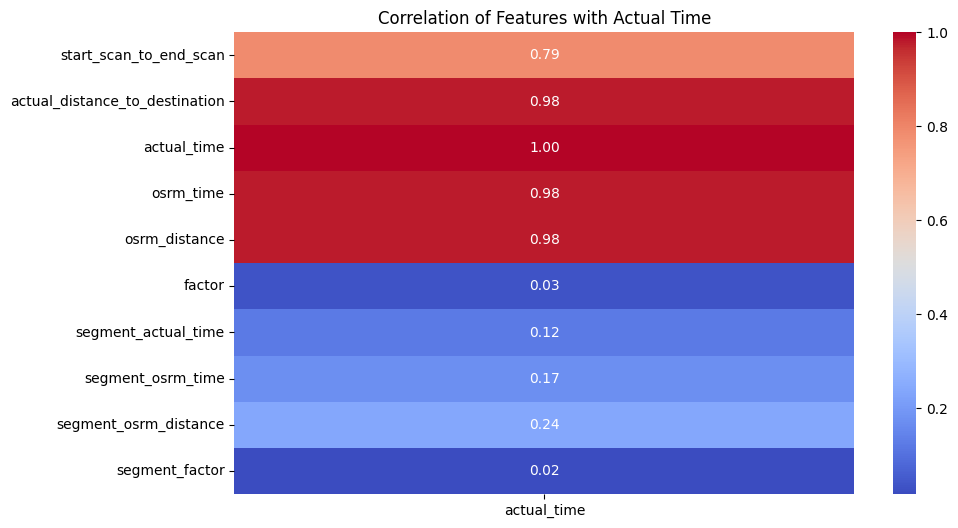

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix[['actual_time']], annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation of Features with Actual Time')
plt.show()

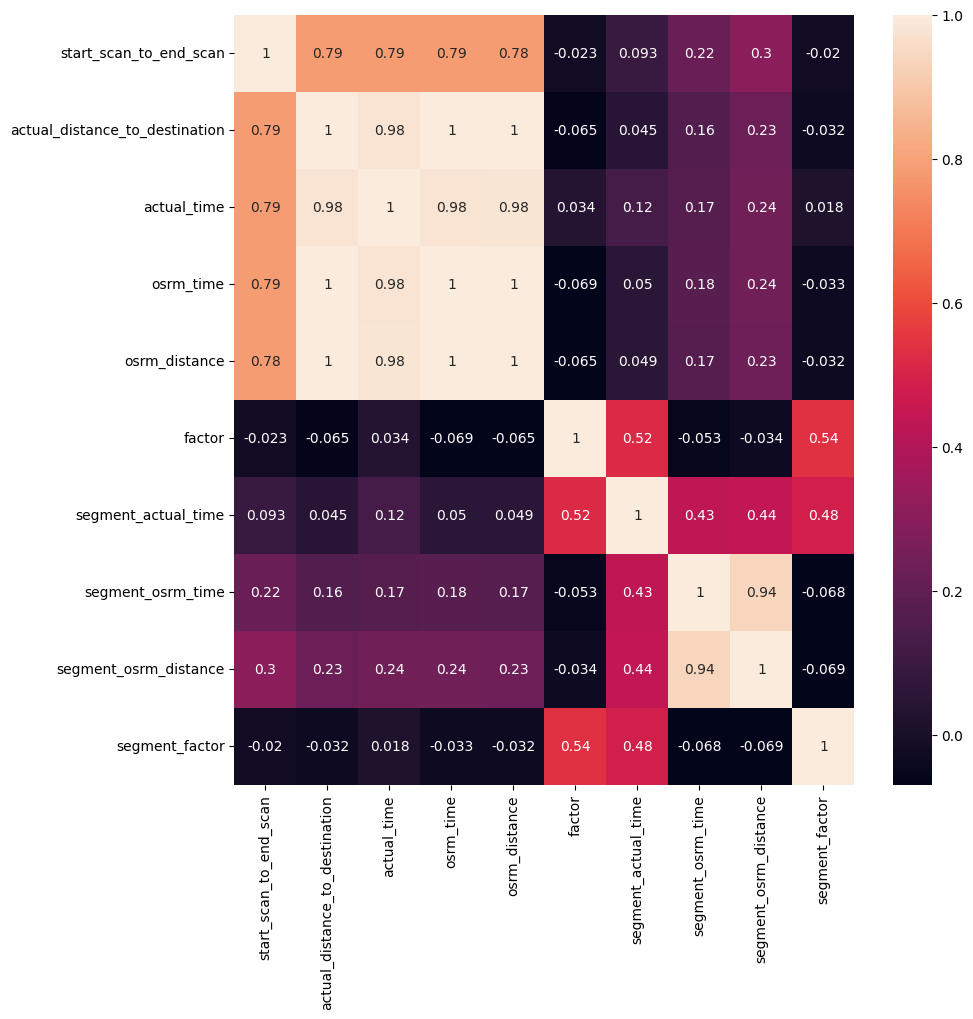

In [ ]:
numeric_cols = delhivery_data2_cleaned.select_dtypes(include=['float64']).columns
correlation_matrix = delhivery_data2_cleaned[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

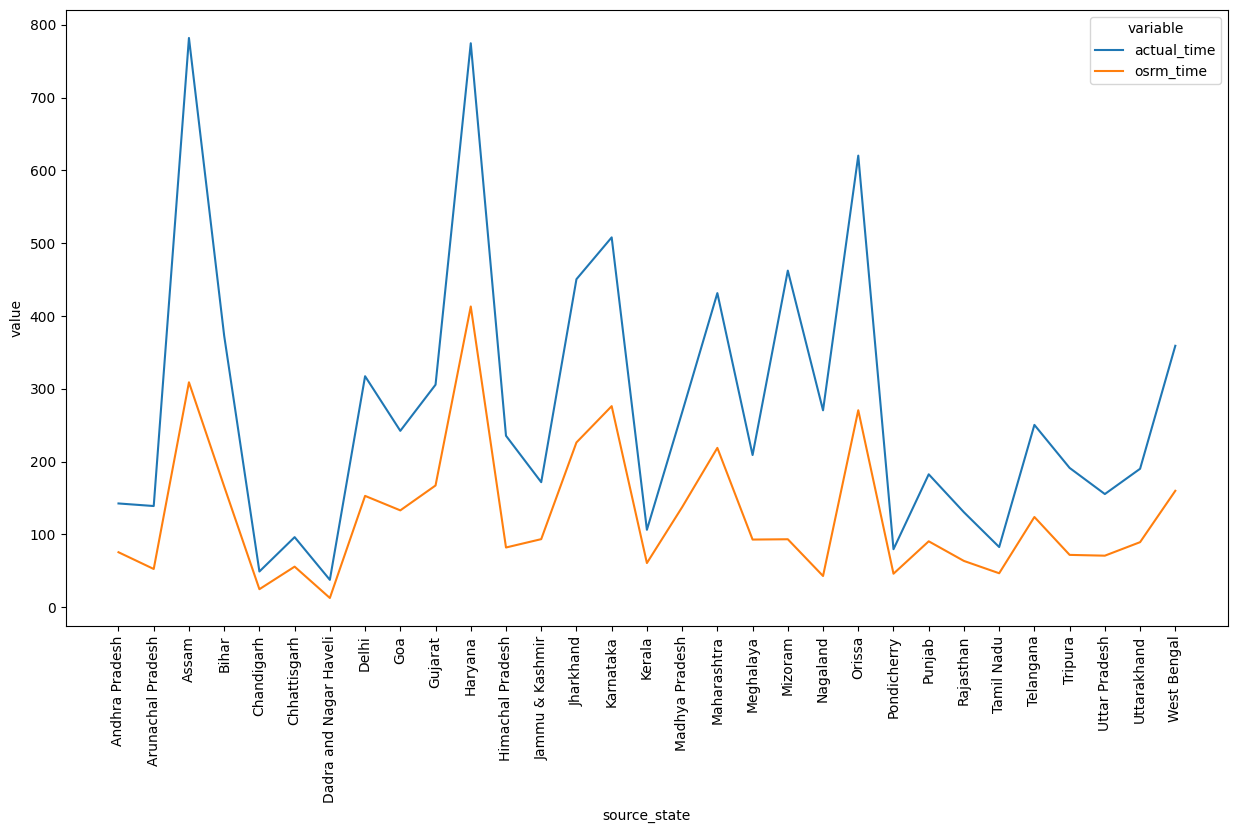

In [ ]:
plt.figure(figsize=(15,8))
sns.lineplot(data=x1,x='source_state',y='value',hue='variable')
plt.xticks(rotation=90)
plt.show()

In [ ]:
x1=delhivery_data2_cleaned.groupby('source_state').agg({'actual_distance_to_destination':'mean','osrm_distance':'mean'}).reset_index()
x1=pd.melt(x1, id_vars=['source_state'], value_vars=['actual_distance_to_destination', 'osrm_distance'])
x1

,source_state,variable,value
0,Andhra Pradesh,actual_distance_to_destination,81.114747
1,Arunachal Pradesh,actual_distance_to_destination,45.982993
2,Assam,actual_distance_to_destination,337.118676
3,Bihar,actual_distance_to_destination,192.910490
4,Chandigarh,actual_distance_to_destination,21.319882
...,...,...,...
57,Telangana,osrm_distance,167.472510
58,Tripura,osrm_distance,101.577660
59,Uttar Pradesh,osrm_distance,89.679691
60,Uttarakhand,osrm_distance,95.041100


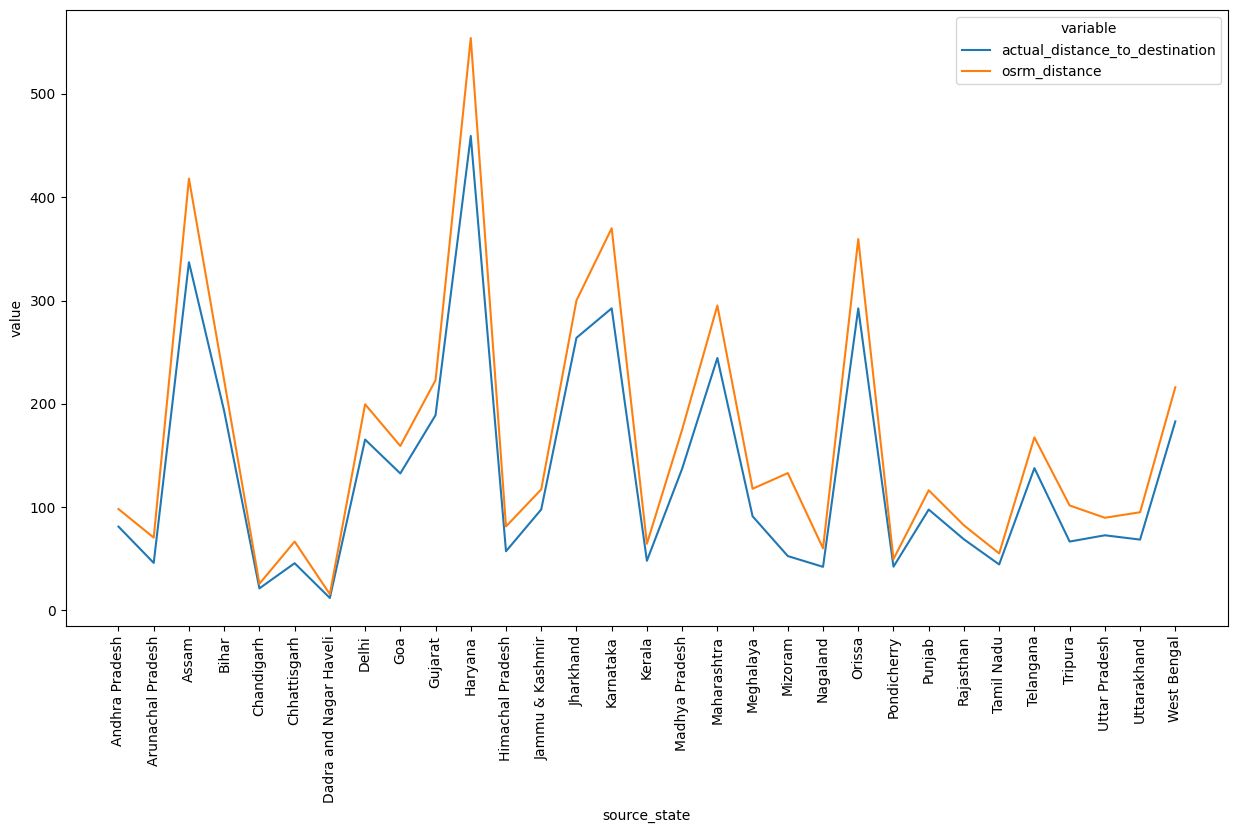

In [ ]:
plt.figure(figsize=(15,8))
sns.lineplot(data=x1,x='source_state',y='value',hue='variable')
plt.xticks(rotation=90)
plt.show()

# Linear Regression

In [ ]:
# Load data from a CSV file
deliver_data = pd.read_csv('deliver_data.csv', sep=',')

In [ ]:
deliver_data_copy = deliver_data.copy()

In [ ]:
deliver_data.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,1,5917,1356,0,5919,497,48,495,740,10055,...,614,2,48,9,38,1060,3,2018,1,20
1,1,5917,1356,0,5919,497,48,495,740,10055,...,614,2,48,9,38,1060,3,2018,1,20
2,1,5917,1356,0,5919,497,48,495,740,10055,...,614,2,48,9,38,1060,3,2018,1,20
3,1,5917,1356,0,5919,497,48,495,740,10055,...,614,2,48,9,38,1060,3,2018,1,20
4,1,5917,1356,0,5919,497,48,495,740,10055,...,614,2,48,9,38,1060,3,2018,1,20


In [ ]:
deliver_data.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor',
       'destination', 'dest_state', 'dest_City', 'dest_place', 'dest_code',
       'source', 'source_state', 'source_City', 'source_place', 'source_code',
       'trip_creation_year', 'trip_creation_month', 'trip_creation_day'],
      dtype='object')

In [ ]:
X = deliver_data['od_start_time']

In [ ]:
X = deliver_data['od_end_time']

In [ ]:
X = deliver_data['osrm_time']

In [ ]:
X = deliver_data['osrm_distance']

In [ ]:
X = deliver_data['osrm_distance']

In [ ]:
X = deliver_data['segment_osrm_time']

In [ ]:
X = deliver_data['segment_osrm_distance']

In [ ]:
X = deliver_data['cutoff_factor']

In [ ]:
X = deliver_data['source_center']

In [ ]:
X = deliver_data['actual_distance_to_destination']

In [ ]:
y = deliver_data['actual_time']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2529)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((101406,), (43461,), (101406,), (43461,))

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train.values.reshape(-1, 1),y_train)

LinearRegression()

In [ ]:
print(f"Koefisien: {model.coef_}")
print(f"Intersep: {model.intercept_}")

Koefisien: [1.69643347]
Intersep: 19.57497269418195


In [ ]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

In [ ]:
y_pred

array([171.99387321, 244.24938168, 162.25929159, ..., 357.4907572 ,
       999.71761157, 505.77723234])

In [ ]:
mean_absolute_error(y_test,y_pred)
mean_absolute_percentage_error(y_test,y_pred)
mean_squared_error(y_test,y_pred)

15710.847307662985

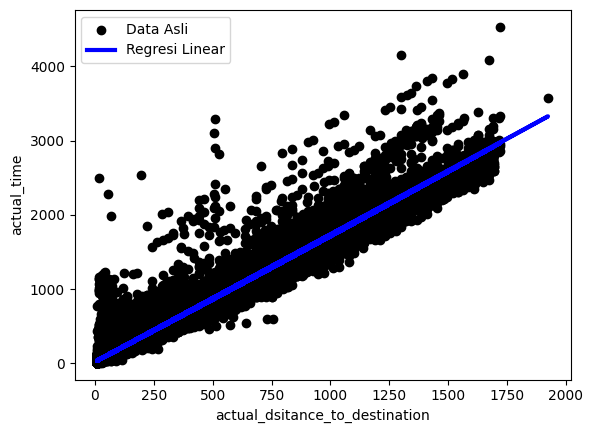

In [ ]:
plt.scatter(X_test, y_test, color='black', label='Data Asli')
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Regresi Linear')
plt.xlabel('od_start_time')
plt.xlabel('od_end_time')
plt.xlabel('osrm_time')
plt.xlabel('osrm_distance')
plt.xlabel('segment_osrm_time')
plt.xlabel('segment_osrm_distance')
plt.xlabel('cutoff_factor')
plt.xlabel('actual_dsitance_to_destination')
plt.ylabel('actual_time')
plt.legend()
plt.show()

Penjelasan:

Gambar menunjukkan plot sebar dengan garis regresi. Sumbu x adalah "cutoff_factor", dan sumbu y adalah "segment_actual_time". Titik hitam melambangkan titik data asli, dan garis biru melambangkan garis regresi linier.

Plot sebar menunjukkan korelasi positif yang lemah antara "cutoff_factor" dan "segment_actual_time". Artinya, seiring dengan peningkatan "faktor_pemutusan", "waktu_aktual_segmen" juga cenderung meningkat, namun hubungannya tidak terlalu kuat.

Garis regresi menunjukkan hubungan linier antara kedua variabel, namun tidak terlalu cocok untuk data. Garis regresi sangat dekat dengan sumbu y, yang menunjukkan bahwa model tidak mampu memprediksi "segment_actual_time" dengan baik berdasarkan "cutoff_factor".

# Clustering With KMeans

### Data Cleaning

In [ ]:
delhivery_data3_cleaned =delhivery_data3_cleaned.copy()

In [ ]:
# Load data
delhivery_data3_cleaned = pd.read_csv('/content/delhivery_data3_cleaned.csv')

In [ ]:
delhivery_data3_cleaned.head()

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20


In [ ]:
delhivery_data3_cleaned['trip_creation_time']=pd.to_datetime(delhivery_data3_cleaned['trip_creation_time'])
delhivery_data3_cleaned['od_start_time']=pd.to_datetime(delhivery_data3_cleaned['od_start_time'])
delhivery_data3_cleaned['od_end_time']=pd.to_datetime(delhivery_data3_cleaned['od_end_time'])

In [ ]:
delhivery_data3_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 38 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Unnamed: 0                      144867 non-null  int64         
 1   data                            144867 non-null  object        
 2   trip_creation_time              144867 non-null  datetime64[ns]
 3   route_schedule_uuid             144867 non-null  object        
 4   route_type                      144867 non-null  object        
 5   trip_uuid                       144867 non-null  object        
 6   source_center                   144867 non-null  object        
 7   source_name                     144867 non-null  object        
 8   destination_center              144867 non-null  object        
 9   destination_name                144867 non-null  object        
 10  od_start_time                   144867 non-null  datetim

In [ ]:
# Cek apakah terdapat duplikat di data kita
print(f"Terdapat {delhivery_data3_cleaned.duplicated().sum()} baris duplikat di data kita")

Terdapat 0 baris duplikat di data kita


In [ ]:
# cek apakah ada typo pada kolom string/object

kolom_string = ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
                     'trip_uuid', 'source_center', 'source_name', 'destination_center',
                     'destination_name', 'od_start_time', 'od_end_time', 'cutoff_timestamp',
                  'destination', 'dest_state', 'dest_City', 'dest_place', 'dest_code',
                    'source', 'source_state', 'source_City', 'source_place', 'source_code',
                  'trip_creation_month']

for col in delhivery_data3_cleaned[kolom_string]:
  print(delhivery_data3_cleaned[col].unique())

['training' 'test']
<DatetimeArray>
['2018-09-20 02:35:36.476840', '2018-09-23 06:42:06.021680',
 '2018-09-14 15:42:46.437249', '2018-09-13 20:44:19.424489',
 '2018-09-29 22:21:45.149226', '2018-09-17 21:26:00.454695',
 '2018-09-12 01:33:48.711350', '2018-10-01 16:00:45.719099',
 '2018-09-27 14:16:14.819357', '2018-09-13 16:41:41.992300',
 ...
 '2018-09-13 20:47:45.942988', '2018-10-01 19:56:20.111591',
 '2018-09-23 01:31:09.129173', '2018-10-01 18:17:37.047270',
 '2018-09-26 14:05:52.096792', '2018-09-26 19:50:29.657378',
 '2018-09-14 18:45:34.164734', '2018-09-22 11:30:41.399439',
 '2018-09-17 11:35:28.838714', '2018-09-20 16:24:28.436231']
Length: 14817, dtype: datetime64[ns]
['thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef'
 'thanos::sroute:ff52ef7a-4d0d-4063-9bfe-cc211728881b'
 'thanos::sroute:a16bfa03-3462-4bce-9c82-5784c7d315e6' ...
 'thanos::sroute:72cf9feb-f4e3-4a55-b92a-0b686ee8fabc'
 'thanos::sroute:5e08be79-8a4c-4a91-a514-5350403c0e31'
 'thanos::sroute:a3c30562-87e5-47

In [ ]:
print(delhivery_data3_cleaned.dtypes)

Unnamed: 0                                 int64
data                                      object
trip_creation_time                datetime64[ns]
route_schedule_uuid                       object
route_type                                object
trip_uuid                                 object
source_center                             object
source_name                               object
destination_center                        object
destination_name                          object
od_start_time                     datetime64[ns]
od_end_time                       datetime64[ns]
start_scan_to_end_scan                   float64
is_cutoff                                   bool
cutoff_factor                              int64
cutoff_timestamp                          object
actual_distance_to_destination           float64
actual_time                              float64
osrm_time                                float64
osrm_distance                            float64
factor              

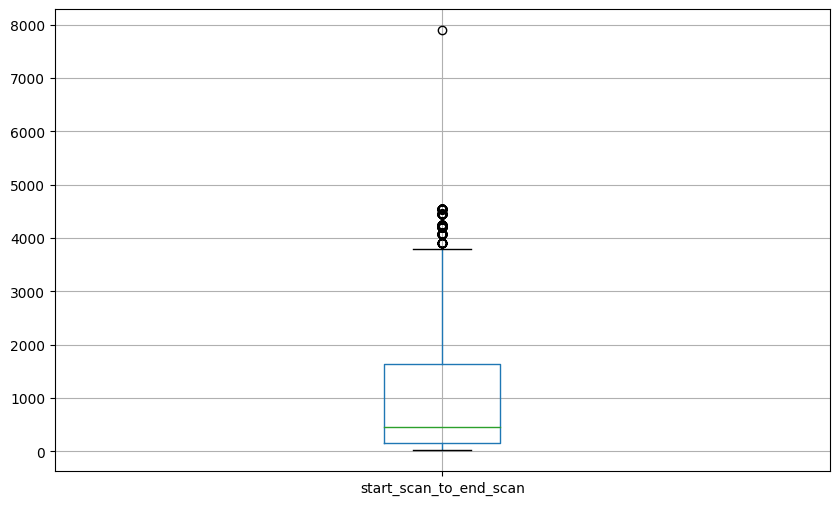

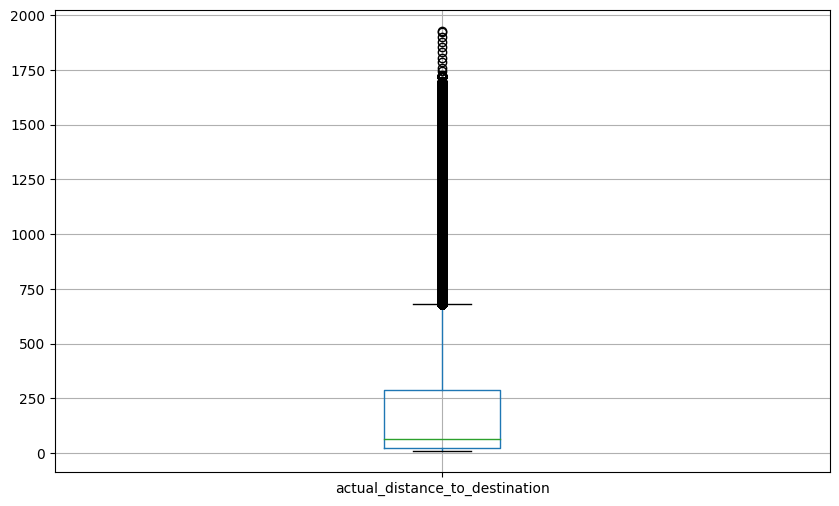

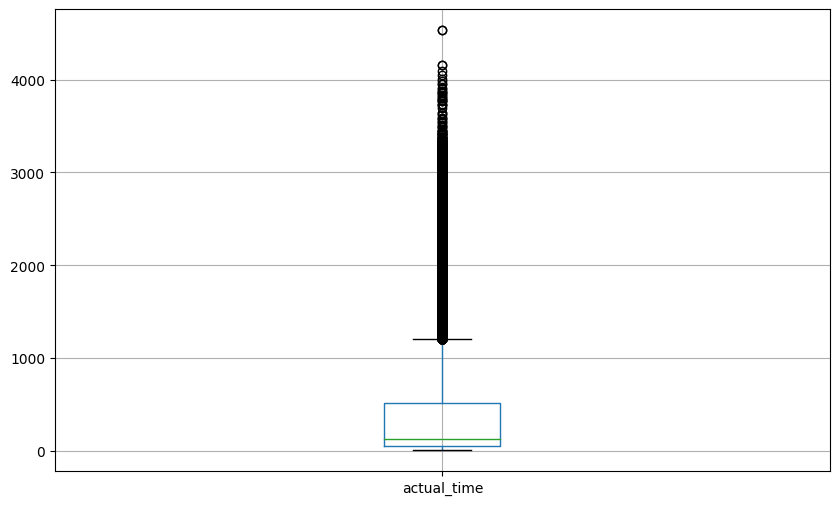

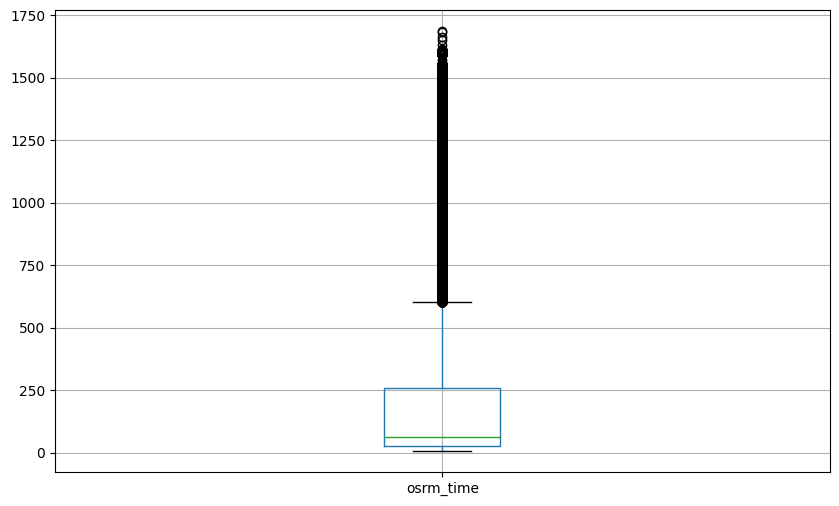

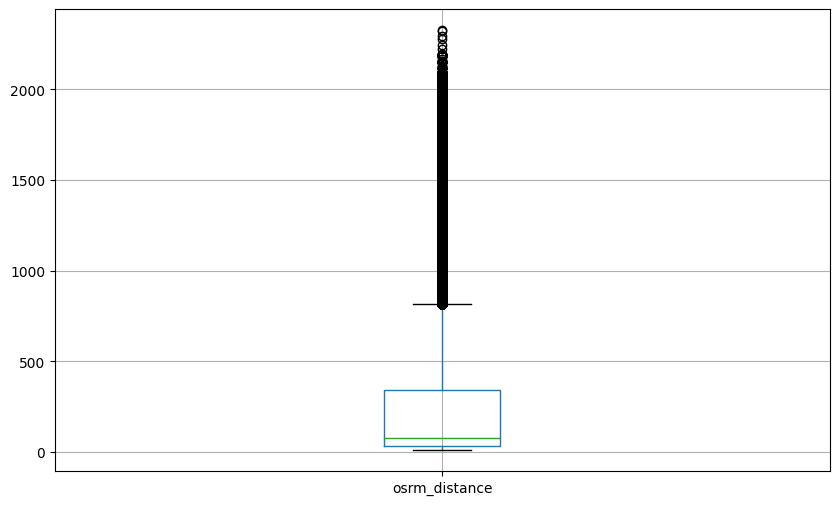

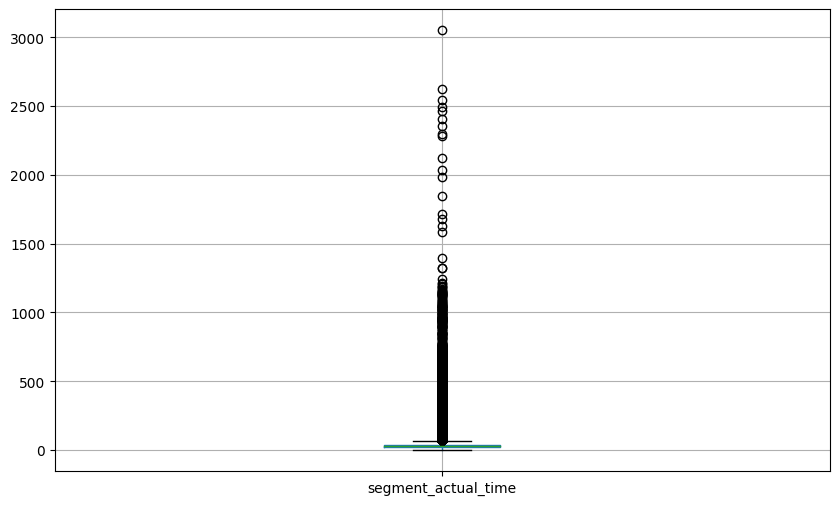

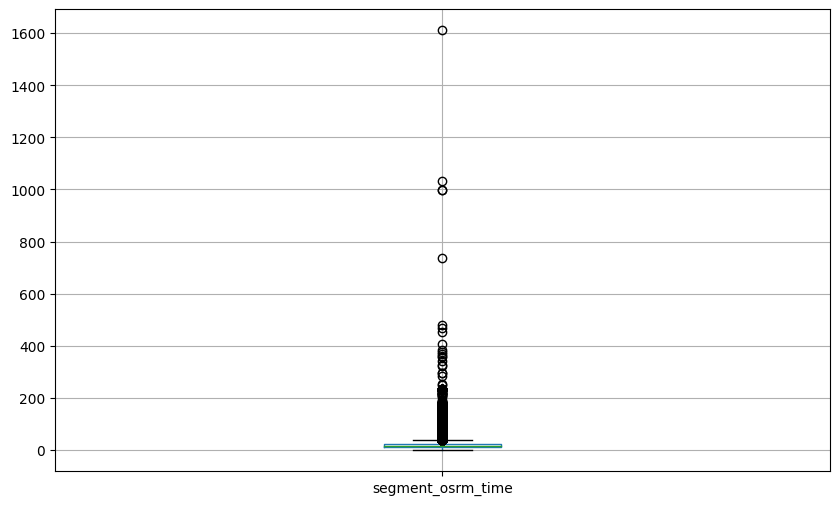

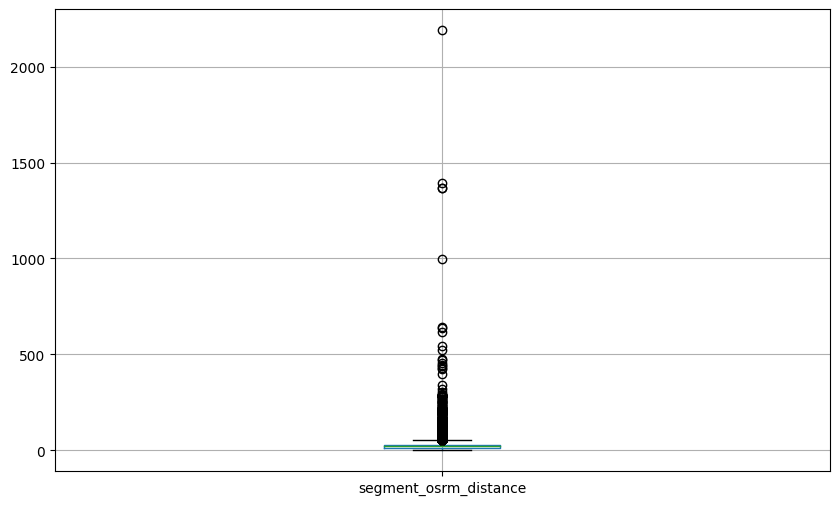

In [ ]:
# cek outlier untuk variabel numerik yaitu start_scan_to_end_scan, cutoff_factor, cutoff_timestamp,
# actual_distance_to_destination, actual_time, osrm_time, osrm_distance, factor, segment_actual_time, segment_osrm_time
# segment_osrm_distance, segment_factor

numerik = ['start_scan_to_end_scan', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
  'segment_osrm_distance']

for i in delhivery_data3_cleaned[numerik]:
  plt.figure(figsize=(10,6))
  delhivery_data3_cleaned.boxplot(column=[i])

### Feature Engineering

Feature Engineering untuk route_type

In [ ]:
delhivery_data3_cleaned.head(35)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["route_type"].value_counts())

Total kategori Route Type:
 route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['route_type']= label_encoder.fit_transform(delhivery_data3_cleaned['route_type'])

Kode:
FTL: 1
Carting: 0

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Feature Engineering untuk data

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["data"].value_counts())

Total kategori Route Type:
 data
training    104858
test         40009
Name: count, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['data']= label_encoder.fit_transform(delhivery_data3_cleaned['data'])

Kode

Training: 1

Test: 0

Feature Engineering route_schedule_uuid


In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["route_schedule_uuid"].value_counts())

Total kategori Route Type:
 route_schedule_uuid
thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069fbcea9    1812
thanos::sroute:0456b740-1dad-4929-bbe0-87d8843f5a10    1608
thanos::sroute:dca6268f-741a-4d1a-b1b0-aab13095a366    1605
thanos::sroute:a1b25549-1e77-498f-8538-00292e5bd5a2    1285
thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e5720d    1280
                                                       ... 
thanos::sroute:d563d17e-2123-40a4-9eec-40018966caba       1
thanos::sroute:036f372d-28d8-4d19-877c-6277077ad09e       1
thanos::sroute:e00eb6aa-d792-4b28-81fa-fdee413ef326       1
thanos::sroute:889b9cf5-da6a-48ce-b3bd-6983c8090164       1
thanos::sroute:404cbabf-d2a5-4e46-bf79-8b3c518f082b       1
Name: count, Length: 1504, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['route_schedule_uuid']= label_encoder.fit_transform(delhivery_data3_cleaned['route_schedule_uuid'])

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode:

thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...	: 1348

thanos::sroute:ff52ef7a-4d0d-4063-9bfe-cc21172...	: 1489

thanos::sroute:a16bfa03-3462-4bce-9c82-5784c7d...	: 905

thanos::sroute:76951383-1608-44e4-a284-46d92e8...	: 659

thanos::sroute:0904e75c-b3ac-4278-96cf-802835a...	: 43



Feature Engineering untuk trip_uuid

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["trip_uuid"].value_counts())

Total kategori Route Type:
 trip_uuid
trip-153811219535896559    101
trip-153846035308581166    101
trip-153802363942560700    101
trip-153759210483476123    101
trip-153819749763881430    101
                          ... 
trip-153807169820740041      1
trip-153815586768995663      1
trip-153823299365493206      1
trip-153733174477629450      1
trip-153694467298919626      1
Name: count, Length: 14817, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['trip_uuid']= label_encoder.fit_transform(delhivery_data3_cleaned['trip_uuid'])

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode:

trip-153741093647649320	: 5846

trip-153768492602129387	: 8085

trip-153693976643699843	: 1869

trip-153687145942424248	: 1291

trip-153825970514894360	: 12295

Feature Engineering untuk Source_center

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["source_center"].value_counts())

Total kategori Route Type:
 source_center
IND000000ACB    23347
IND562132AAA     9975
IND421302AAG     9088
IND411033AAA     4061
IND501359AAE     3340
                ...  
IND741121AAA        1
IND207123AAA        1
IND242001AAA        1
IND222001AAA        1
IND741101AAB        1
Name: count, Length: 1508, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['source_center']= label_encoder.fit_transform(delhivery_data3_cleaned['source_center'])

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode:

IND388121AAA	: 497

IND388620AAB	: 500

IND421302AAG	: 605

IND400011AAA	: 522

IND562132AAA	: 921

IND560099AAB	: 908

IND141003AAB	: 98

IND142026AAA  : 103

IND141109AAA	: 100

Feature Engineering destination center

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["destination_center"].value_counts())

Total kategori Route Type:
 destination_center
IND000000ACB    15192
IND562132AAA    11019
IND421302AAG     5492
IND501359AAE     5142
IND712311AAA     4892
                ...  
IND520011AAA        1
IND741201AAC        1
IND400705AAA        1
IND110046AAA        1
IND504215AAA        1
Name: count, Length: 1481, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['destination_center']= label_encoder.fit_transform(delhivery_data3_cleaned['destination_center'])

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode destination center:

IND388620AAB	495

IND388320AAA	494

IND411033AAA	563

IND400072AAD	525

IND560099AAB	900

IND683511AAA	1163

IND142026AAA	103

IND141109AAA	100

IND000000ACA	5

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,Anand_VUNagar_DC (Gujarat),495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,Khambhat_MotvdDPP_D (Gujarat),494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kolom feature engineering untuk source name

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["source_name"].value_counts())

Total kategori Route Type:
 source_name
Gurgaon_Bilaspur_HB (Haryana)            23347
Bangalore_Nelmngla_H (Karnataka)          9975
Bhiwandi_Mankoli_HB (Maharashtra)         9088
Pune_Tathawde_H (Maharashtra)             4061
Hyderabad_Shamshbd_H (Telangana)          3340
                                         ...  
Shahjhnpur_NavdaCln_D (Uttar Pradesh)        1
Soro_UttarDPP_D (Orissa)                     1
Kayamkulam_Bhrnikvu_D (Kerala)               1
Krishnanagar_AnadiDPP_D (West Bengal)        1
Faridabad_Old (Haryana)                      1
Name: count, Length: 1499, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['source_name']= label_encoder.fit_transform(delhivery_data3_cleaned['source_name'])

In [ ]:
delhivery_data3_cleaned.head(40)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,Khambhat_MotvdDPP_D (Gujarat),...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,Anand_Vaghasi_IP (Gujarat),...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode untuk Source Name:

Anand_VUNagar_DC (Gujarat): 48

Khambhat_MotvdDPP_D (Gujarat): 762

Bhiwandi_Mankoli_HB (Maharashtra): 206

LowerParel_CP (Maharashtra): 854

Bangalore_Nelmngla_H (Karnataka): 115

Bengaluru_Bomsndra_HB (Karnataka): 159

Ludhiana_GillChwk_DC (Punjab): 857

Jagraon_DC (Punjab): 625

Raikot_DC (Punjab): 1186

Kolom feature engineering untuk destination name

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["destination_name"].value_counts())

Total kategori Route Type:
 destination_name
Gurgaon_Bilaspur_HB (Haryana)        15453
Bangalore_Nelmngla_H (Karnataka)     11019
Bhiwandi_Mankoli_HB (Maharashtra)     5492
Hyderabad_Shamshbd_H (Telangana)      5142
Kolkata_Dankuni_HB (West Bengal)      4892
                                     ...  
Hyd_Trimulgherry_Dc (Telangana)          1
Vijayawada (Andhra Pradesh)              1
Baghpat_Barout_D (Uttar Pradesh)         1
Mumbai_Sanpada_CP (Maharashtra)          1
Basta_Central_DPP_1 (Orissa)             1
Name: count, Length: 1468, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['destination_name']= label_encoder.fit_transform(delhivery_data3_cleaned['destination_name'])

In [ ]:
delhivery_data3_cleaned.head(20)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,MotvdDPP,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,Vaghasi,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode:

Khambhat_MotvdDPP_D (Gujarat): 740

Anand_Vaghasi_IP (Gujarat): 45

Pune_Tathawde_H (Maharashtra): 1148

Mumbai_Chndivli_PC (Maharashtra): 936

Bengaluru_Bomsndra_HB (Karnataka): 156

Aluva_Peedika_H (Kerala): 26

Jagraon_DC (Punjab): 598

Raikot_DC (Punjab): 1162

Ludhiana_MilrGanj_HB (Punjab): 833

Feature Engineering untuk 'is_cutoff'

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["is_cutoff"].value_counts())

Total kategori Route Type:
 is_cutoff
True     118749
False     26118
Name: count, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['is_cutoff']= label_encoder.fit_transform(delhivery_data3_cleaned['is_cutoff'])

In [ ]:
delhivery_data3_cleaned[['is_cutoff']].head(40)

,is_cutoff
0,1
1,1
2,1
3,1
4,0
5,1
6,1
7,1
8,1
9,0


Feature Engineering untuk dest_place

In [ ]:
print("Total kategori Destination Place:\n", delhivery_data3_cleaned["dest_place"].value_counts())

Total kategori Destination Place:
 dest_place
Bilaspur    18065
Nelmngla    11019
Central      9373
Hub          6939
Mankoli      5586
            ...  
KotyamRD        1
DivrsnRd        1
DMComDPP        1
MnbzrDPP        1
VUNagar         1
Name: count, Length: 1130, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['dest_place']= label_encoder.fit_transform(delhivery_data3_cleaned['dest_place'])

In [ ]:
delhivery_data3_cleaned[['dest_place']].head(10)

,dest_place
0,614
1,614
2,614
3,614
4,614
5,1036
6,1036
7,1036
8,1036
9,1036


Kode:

Motvdpp:  614

Vaghasi:  1036

Tathawde: 982

Chndivii: 178

Bomnsdra: 139

Peedika: 738

DC: 219

Mirlganj: 587

Dest_Code

In [ ]:
delhivery_data3_cleaned.head(10)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,D,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,IP,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["dest_code"].value_counts())

Total kategori Route Type:
 dest_code
H             50152
HB            31064
D             26424
I             10648
IP             3887
DPC            3034
L              2827
H_1            2734
H_6            2246
DC             2190
I_2            2009
P               834
PC              797
D_1             694
D_2             679
I_1             640
DPP_1           450
H_2             409
Dc              350
DPP_2           340
I_4             253
M               248
I_7             243
Pc              195
D_3             186
Nagar_DPC       178
I_21            148
I_3             145
H_4             135
DPP_3           117
GW               94
R_8              72
I_20             68
L_8              65
RPC              51
C                46
D_10             45
D_7              44
D_5              34
Layout_PC        25
D_12             22
D_9              12
D_8              12
DPP_4            10
L_23              6
Gateway           3
INT               1
CP                1
Na

In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['dest_code']= label_encoder.fit_transform(delhivery_data3_cleaned['dest_code'])

In [ ]:
delhivery_data3_cleaned.head(10)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,Anand_VUNagar_DC,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,Khambhat_MotvdDPP_D,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Kode:

D : 2

IP : 29

Source

In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["source"].value_counts())

Total kategori Route Type:
 source
Gurgaon_Bilaspur_HB         23347
Bangalore_Nelmngla_H         9975
Bhiwandi_Mankoli_HB          9088
Pune_Tathawde_H              4061
Hyderabad_Shamshbd_H         3340
                            ...  
Shahjhnpur_NavdaCln_D           1
Soro_UttarDPP_D                 1
Kayamkulam_Bhrnikvu_D           1
Krishnanagar_AnadiDPP_D         1
Faridabad_Old                   1
Name: count, Length: 1499, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['source']= label_encoder.fit_transform(delhivery_data3_cleaned['source'])

In [ ]:
delhivery_data3_cleaned.head(10)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


Anand_VUNagar_DC: 48

Khambhat_MotvdDPP_D: 762

Source Status

In [ ]:
delhivery_data3_cleaned.head(10)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,Gujarat,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,Gujarat,Khambhat,MotvdDPP,D,2018,September,20


In [ ]:
print("Total kategori Route Type:\n", delhivery_data3_cleaned["source_state"].value_counts())

Total kategori Route Type:
 source_state
Haryana                   27792
Maharashtra               21401
Karnataka                 19578
Tamil Nadu                 7494
Gujarat                    7202
Uttar Pradesh              7137
Telangana                  6496
West Bengal                5963
Andhra Pradesh             5539
Rajasthan                  5267
Punjab                     4704
Delhi                      4398
Bihar                      4190
Madhya Pradesh             4021
Assam                      2875
Jharkhand                  2597
Kerala                     2413
Orissa                     2094
Uttarakhand                1162
Himachal Pradesh            587
Goa                         514
Chandigarh                  507
Arunachal Pradesh           245
Chhattisgarh                229
Jammu & Kashmir             226
Meghalaya                    86
Pondicherry                  49
Nagaland                     40
Dadra and Nagar Haveli       30
Mizoram                      26

In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned['source_state']= label_encoder.fit_transform(delhivery_data3_cleaned['source_state'])

In [ ]:
delhivery_data3_cleaned.head(10)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,Anand,VUNagar,DC,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,Anand,VUNagar,DC,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,Anand,VUNagar,DC,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,Anand,VUNagar,DC,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,Anand,VUNagar,DC,2018,September,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,Khambhat,MotvdDPP,D,2018,September,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,Khambhat,MotvdDPP,D,2018,September,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,Khambhat,MotvdDPP,D,2018,September,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,Khambhat,MotvdDPP,D,2018,September,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,Khambhat,MotvdDPP,D,2018,September,20


source_City, source_place, source_code, trip_creation_year, trip_creation_month, trip_creation_day

In [ ]:
print("Value counts for multiple columns:\n", delhivery_data3_cleaned[["source_City", "source_place", "source_code", "trip_creation_month"]].value_counts())

Value counts for multiple columns:
 source_City   source_place  source_code  trip_creation_month
Gurgaon       Bilaspur      HB           September              20383
Bangalore     Nelmngla      H            September               8835
Bhiwandi      Mankoli       HB           September               7706
Pune          Tathawde      H            September               3792
Hyderabad     Shamshbd      H            September               3019
                                                                ...  
Vadodara      Karelibaug    DC           September                  1
Islampur      Shantanu      D            October                    1
Pachora       PcrrdDPP      D            September                  1
Islampure     Central       DPP_2        October                    1
Thirthahalli  NadthiCx      D            September                  1
Name: count, Length: 2377, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned["source_City"] = label_encoder.fit_transform(delhivery_data3_cleaned["source_City"])
delhivery_data3_cleaned["source_place"] = label_encoder.fit_transform(delhivery_data3_cleaned["source_place"])
delhivery_data3_cleaned["source_code"] = label_encoder.fit_transform(delhivery_data3_cleaned["source_code"])
delhivery_data3_cleaned["trip_creation_month"] = label_encoder.fit_transform(delhivery_data3_cleaned["trip_creation_month"])

In [ ]:
delhivery_data3_cleaned.head(10)

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
5,5,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,599,634,2,2018,1,20
6,6,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,599,634,2,2018,1,20
7,7,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,599,634,2,2018,1,20
8,8,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,599,634,2,2018,1,20
9,9,1,2018-09-20 02:35:36.476840,1356,0,5919,500,762,494,45,...,1036,29,762,9,599,634,2,2018,1,20


destination, dest_state, dest_city

In [ ]:
print("Value counts for multiple columns:\n", delhivery_data3_cleaned[["destination", "dest_state", "dest_City"]].value_counts())

Value counts for multiple columns:
 destination            dest_state     dest_City   
Gurgaon_Bilaspur_HB    Haryana        Gurgaon         15453
Bangalore_Nelmngla_H   Karnataka      Bangalore       11019
Bhiwandi_Mankoli_HB    Maharashtra    Bhiwandi         5492
Hyderabad_Shamshbd_H   Telangana      Hyderabad        5142
Kolkata_Dankuni_HB     West Bengal    Kolkata          4892
                                                      ...  
Manthuka_Central_D_1   Kerala         Manthuka            1
Hyd_Trimulgherry_Dc    Telangana      Hyd                 1
Durg_Bhilai_DC         Chhattisgarh   Durg                1
North Delhi            Delhi          North Delhi         1
Tilhar_SingCLNY_D      Uttar Pradesh  Tilhar              1
Name: count, Length: 1468, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned["destination"] = label_encoder.fit_transform(delhivery_data3_cleaned["destination"])
delhivery_data3_cleaned["dest_state"] = label_encoder.fit_transform(delhivery_data3_cleaned["dest_state"])
delhivery_data3_cleaned["dest_City"] = label_encoder.fit_transform(delhivery_data3_cleaned["dest_City"])

In [ ]:
delhivery_data3_cleaned.head()

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,dest_place,dest_code,source,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,614,2,48,9,38,1060,3,2018,1,20


Saya akan memecah od_start_time, od_end_time, dan cutoff_factor menjadi 3 bagian (sama seperti trip creation time)

In [ ]:
delhivery_data3_cleaned['od_start_year'] =delhivery_data3_cleaned['od_start_time'].dt.year
delhivery_data3_cleaned['od_start_month'] =delhivery_data3_cleaned['od_start_time'].dt.month_name()
delhivery_data3_cleaned['od_start_day'] =delhivery_data3_cleaned['od_start_time'].dt.day
delhivery_data3_cleaned

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day,od_start_year,od_start_month,od_start_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,September,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,144862,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,10,1131,519,22,2018,1,20,2018,September,20
144863,144863,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,10,1131,519,22,2018,1,20,2018,September,20
144864,144864,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,10,1131,519,22,2018,1,20,2018,September,20
144865,144865,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,10,1131,519,22,2018,1,20,2018,September,20


In [ ]:
print("Value counts for multiple columns:\n", delhivery_data3_cleaned[["od_start_month"]].value_counts())

Value counts for multiple columns:
 od_start_month
September         125805
October            19062
Name: count, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned["od_start_month"] = label_encoder.fit_transform(delhivery_data3_cleaned["od_start_month"])

In [ ]:
delhivery_data3_cleaned.head()

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,source_state,source_City,source_place,source_code,trip_creation_year,trip_creation_month,trip_creation_day,od_start_year,od_start_month,od_start_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,1,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,1,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,1,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,1,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,9,38,1060,3,2018,1,20,2018,1,20


In [ ]:
delhivery_data3_cleaned['od_end_year'] =delhivery_data3_cleaned['od_start_time'].dt.year
delhivery_data3_cleaned['od_end_month'] =delhivery_data3_cleaned['od_start_time'].dt.month_name()
delhivery_data3_cleaned['od_end_day'] =delhivery_data3_cleaned['od_end_time'].dt.day
delhivery_data3_cleaned

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,source_code,trip_creation_year,trip_creation_month,trip_creation_day,od_start_year,od_start_month,od_start_day,od_end_year,od_end_month,od_end_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,September,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,September,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,September,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,September,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,September,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,144862,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,22,2018,1,20,2018,1,20,2018,September,20
144863,144863,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,22,2018,1,20,2018,1,20,2018,September,20
144864,144864,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,22,2018,1,20,2018,1,20,2018,September,20
144865,144865,1,2018-09-20 16:24:28.436231,1394,0,6227,77,1352,6,520,...,22,2018,1,20,2018,1,20,2018,September,20


In [ ]:
print("Value counts for multiple columns:\n", delhivery_data3_cleaned[["od_end_month"]].value_counts())

Value counts for multiple columns:
 od_end_month
September       125805
October          19062
Name: count, dtype: int64


In [ ]:
label_encoder = preprocessing.LabelEncoder()

delhivery_data3_cleaned["od_end_month"] = label_encoder.fit_transform(delhivery_data3_cleaned["od_end_month"])

In [ ]:
delhivery_data3_cleaned.head()

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,source_code,trip_creation_year,trip_creation_month,trip_creation_day,od_start_year,od_start_month,od_start_day,od_end_year,od_end_month,od_end_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20


In [ ]:
delhivery_data3_cleaned.head()

,Unnamed: 0,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,...,source_code,trip_creation_year,trip_creation_month,trip_creation_day,od_start_year,od_start_month,od_start_day,od_end_year,od_end_month,od_end_day
0,0,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
1,1,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
2,2,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
3,3,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20
4,4,1,2018-09-20 02:35:36.476840,1356,0,5919,497,48,495,740,...,3,2018,1,20,2018,1,20,2018,1,20


In [ ]:
#Dropping fitur yang tidak diperlukan
to_drop = ["trip_creation_time", "od_start_time", "od_end_time"]
delhivery_data3_cleaned = delhivery_data3_cleaned.drop(to_drop, axis=1)

In [ ]:
delhivery_data3_cleaned.describe()

,Unnamed: 0,data,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,source_code,trip_creation_year,trip_creation_month,trip_creation_day,od_start_year,od_start_month,od_start_day,od_end_year,od_end_month,od_end_day
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,...,144867.000000,144867.0,144867.000000,144867.000000,144867.0,144867.000000,144867.000000,144867.0,144867.000000,144867.000000
mean,72433.000000,0.723823,748.994623,0.687941,7431.143711,608.123624,623.733687,638.010085,613.032202,961.262986,...,18.683648,2018.0,0.879075,18.389723,2018.0,0.868417,18.361173,2018.0,0.868417,18.227139
std,41819.645061,0.447107,439.032615,0.463335,4248.562348,455.051644,415.319098,441.239393,414.727810,1037.012769,...,10.178760,0.0,0.326041,7.878764,0.0,0.338038,7.993457,0.0,0.338038,8.267425
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,0.000000,2018.0,0.000000,1.000000,2018.0,0.000000,1.000000,2018.0,0.000000,1.000000
25%,36216.500000,0.000000,338.000000,0.000000,3717.000000,136.000000,213.000000,200.000000,209.000000,161.000000,...,9.000000,2018.0,1.000000,14.000000,2018.0,1.000000,14.000000,2018.0,1.000000,14.000000
50%,72433.000000,1.000000,766.000000,1.000000,7418.000000,605.000000,539.000000,641.000000,520.000000,449.000000,...,23.000000,2018.0,1.000000,19.000000,2018.0,1.000000,19.000000,2018.0,1.000000,20.000000
75%,108649.500000,1.000000,1135.000000,1.000000,11061.000000,921.000000,944.000000,913.000000,934.000000,1634.000000,...,23.000000,2018.0,1.000000,25.000000,2018.0,1.000000,25.000000,2018.0,1.000000,25.000000
max,144866.000000,1.000000,1503.000000,1.000000,14816.000000,1507.000000,1498.000000,1480.000000,1467.000000,7898.000000,...,47.000000,2018.0,1.000000,30.000000,2018.0,1.000000,30.000000,2018.0,1.000000,30.000000


In [ ]:
#Visualization of outlier values
from plotly.subplots import make_subplots
import plotly.graph_objects as go
fig=make_subplots(rows=2,cols=1,subplot_titles=('<i>od_end_month'))
fig.add_trace(go.Box(x=delhivery_data3_cleaned['od_end_month'],name='od_end_month'),row=1,col=1)

fig.update_yaxes(visible=False, showticklabels=False)
fig.update_layout(height=600, width=1000, title_text='<b>Box Plots to Check Outliers', font_size=20)
fig.update_layout(template='plotly_dark', title_x=0.5, font_family='Courier New', showlegend=False)

Tampaknya bersih dari outlier

In [ ]:
# Konversi cutoff_timestamp ke format datetime
delhivery_data3_cleaned['cutoff_timestamp'] = pd.to_datetime(delhivery_data3_cleaned['cutoff_timestamp'], errors='coerce')

In [ ]:
# Cek apakah ada nilai NaN
print(delhivery_data3_cleaned['cutoff_timestamp'].isna().sum())

# Menghapus baris dengan cutoff_timestamp yang NaN
delhivery_data3_cleaned = delhivery_data3_cleaned.dropna(subset=['cutoff_timestamp'])

3429


In [ ]:
# Ekstraksi komponen waktu
delhivery_data3_cleaned['cutoff_year'] = delhivery_data3_cleaned['cutoff_timestamp'].dt.year
delhivery_data3_cleaned['cutoff_month'] = delhivery_data3_cleaned['cutoff_timestamp'].dt.month
delhivery_data3_cleaned['cutoff_day'] = delhivery_data3_cleaned['cutoff_timestamp'].dt.day
delhivery_data3_cleaned['cutoff_hour'] = delhivery_data3_cleaned['cutoff_timestamp'].dt.hour
delhivery_data3_cleaned['cutoff_minute'] = delhivery_data3_cleaned['cutoff_timestamp'].dt.minute
delhivery_data3_cleaned['cutoff_second'] = delhivery_data3_cleaned['cutoff_timestamp'].dt.second

In [ ]:
delhivery_data3_cleaned.describe()

,Unnamed: 0,data,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,od_start_day,od_end_year,od_end_month,od_end_day,cutoff_year,cutoff_month,cutoff_day,cutoff_hour,cutoff_minute,cutoff_second
count,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000,...,141438.000000,141438.0,141438.000000,141438.000000,141438.0,141438.000000,141438.000000,141438.000000,141438.000000,141438.000000
mean,72456.038179,0.720294,748.857719,0.690345,7459.011383,604.353469,620.319101,635.164235,610.625009,980.197062,...,18.347587,2018.0,0.866726,18.208459,2018.0,9.147902,18.275068,10.128806,30.025297,28.082510
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,...,1.000000,2018.0,0.000000,1.000000,2018.0,9.000000,1.000000,0.000000,0.000000,0.000000
25%,36259.250000,0.000000,338.000000,0.000000,3748.000000,136.000000,213.000000,200.000000,209.000000,168.000000,...,14.000000,2018.0,1.000000,14.000000,2018.0,9.000000,14.000000,4.000000,15.000000,19.000000
50%,72447.500000,1.000000,766.000000,1.000000,7455.500000,605.000000,539.000000,635.000000,520.000000,470.000000,...,19.000000,2018.0,1.000000,20.000000,2018.0,9.000000,19.000000,9.000000,30.000000,24.000000
75%,108687.750000,1.000000,1135.000000,1.000000,11106.000000,921.000000,928.000000,911.000000,934.000000,1681.000000,...,25.000000,2018.0,1.000000,25.000000,2018.0,9.000000,25.000000,17.000000,45.000000,35.000000
max,144865.000000,1.000000,1503.000000,1.000000,14816.000000,1507.000000,1498.000000,1480.000000,1467.000000,7898.000000,...,30.000000,2018.0,1.000000,30.000000,2018.0,10.000000,30.000000,23.000000,59.000000,59.000000
std,41814.000017,0.448856,438.695228,0.462353,4254.482779,455.694661,414.195142,442.003918,414.260132,1041.349310,...,8.028617,0.0,0.339872,8.307391,0.0,0.355004,8.184281,7.232594,17.329585,15.190301


In [ ]:
#Dropping fitur yang tidak diperlukan
to_drop = ["cutoff_timestamp"]
delhivery_data3_cleaned = delhivery_data3_cleaned.drop(to_drop, axis=1)

# Clustering

delhivery_data3_cleaned.info()

In [ ]:
delhivery_data3_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141438 entries, 0 to 144865
Data columns (total 46 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      141438 non-null  int64  
 1   data                            141438 non-null  int64  
 2   route_schedule_uuid             141438 non-null  int64  
 3   route_type                      141438 non-null  int64  
 4   trip_uuid                       141438 non-null  int64  
 5   source_center                   141438 non-null  int64  
 6   source_name                     141438 non-null  int64  
 7   destination_center              141438 non-null  int64  
 8   destination_name                141438 non-null  int64  
 9   start_scan_to_end_scan          141438 non-null  float64
 10  is_cutoff                       141438 non-null  int64  
 11  cutoff_factor                   141438 non-null  int64  
 12  actual_distance_to_de

<function matplotlib.pyplot.show(close=None, block=None)>

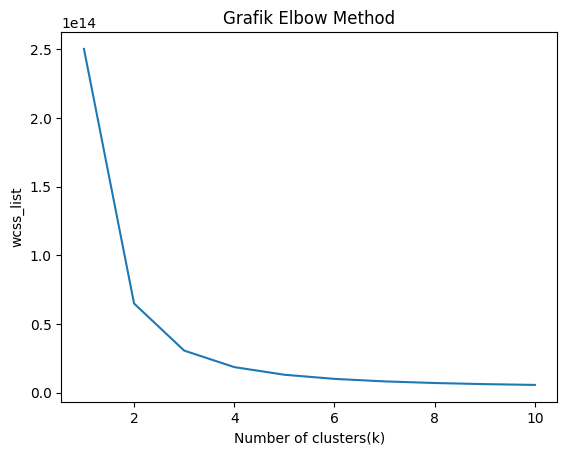

In [ ]:
# menemukan jumlah optimal dari cluster menggunakan elbow method
from sklearn.cluster import KMeans
wcss_list= []  # Inisialisasi list untuk nilai KMeans

# Menggunakan looping untuk iterasi dari 1 sampai 10.
for i in range(1, 11):
    kmeans =KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(delhivery_data3_cleaned)
    wcss_list.append(kmeans.inertia_)
mtp.plot(range(1, 11), wcss_list)
mtp.title('Grafik Elbow Method')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show

In [ ]:
#melakukan training model dengan 3 kluster sesuai dengn titik elbow yang optimal
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(delhivery_data3_cleaned)

In [ ]:
delhivery_data3_cleaned['cluster'] = y_kmeans

In [ ]:
delhivery_data3_cleaned.groupby('cluster').mean()

,Unnamed: 0,data,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,od_start_day,od_end_year,od_end_month,od_end_day,cutoff_year,cutoff_month,cutoff_day,cutoff_hour,cutoff_minute,cutoff_second
cluster,,,,,,,,,,,,,,,,,,,,,
0,24103.084823,0.716909,759.027686,0.692714,7519.020386,592.203035,622.047455,639.153239,617.486934,954.186223,...,18.345527,2018.0,0.863934,18.121340,2018.0,9.152111,18.227081,10.157303,30.051605,27.754192
1,120666.686759,0.728155,748.060340,0.691135,7409.222330,608.315292,625.423074,643.056407,608.177594,981.359944,...,18.647392,2018.0,0.879088,18.561936,2018.0,9.132836,18.642699,10.137846,29.979534,28.253388
2,72283.949117,0.715783,739.521136,0.687191,7449.149235,612.489363,613.476001,623.270728,606.240949,1004.955755,...,18.048868,2018.0,0.857106,17.940675,2018.0,9.158822,17.954080,10.091331,30.044987,28.238318


In [ ]:
# narik masing-masing data untuk tiap kluster ke suatu variabel
delhivery_data3_cleaned_cluster_final0 = delhivery_data3_cleaned[delhivery_data3_cleaned["cluster"]==0]
delhivery_data3_cleaned_cluster_final1 = delhivery_data3_cleaned[delhivery_data3_cleaned["cluster"]==1]
delhivery_data3_cleaned_cluster_final2 = delhivery_data3_cleaned[delhivery_data3_cleaned["cluster"]==2]

In [ ]:
# Menambahkan numerical columns
num_col = ['start_scan_to_end_scan', 'cutoff_factor', 'actual_distance_to_destination', 'actual_time', 'osrm_time',
            'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor',
            'dest_code', 'source_code', 'trip_creation_year', 'trip_creation_day', 'od_start_year', 'od_start_day', 'od_end_year',
            'od_end_day', 'cutoff_year', 'cutoff_day', 'cutoff_hour', 'cutoff_minute', 'cutoff_second']

# Menambahkan categorical columns
cat_col = ['data', 'route_schedule_uuid', 'trip_uuid', 'route_type', 'source_center', 'source_name', 'destination_center', 'destination_name',
            'is_cutoff', 'destination','dest_state', 'dest_City', 'dest_place',
           'source', 'source_state', 'source_City', 'source_place', 'cutoff_month', 'trip_creation_month']

In [ ]:
# Buat fungsi untuk bisa secara otomatis mengembalikan nilai agg dari kolom yang diinginkan
def characteristic_col(x,y,z):
  pd.set_option('display.float_format', lambda x: '%2f' % x)
  print("Total user", len(z))
  for i in z :

    for i in x:
      print(i, ":", (z[i].value_counts() / len(z) *100 ), "\n")

    for n in y:
      print("\n" ,n ,":", z[n].mean())

In [ ]:
# Menambahkan numerical columns
num_col = ['start_scan_to_end_scan', 'cutoff_factor', 'actual_distance_to_destination', 'actual_time', 'osrm_time',
            'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor',
            'dest_code', 'source_code', 'trip_creation_year', 'trip_creation_day', 'od_start_year', 'od_start_day', 'od_end_year',
            'od_end_day', 'cutoff_year', 'cutoff_day', 'cutoff_hour', 'cutoff_minute', 'cutoff_second']

# Menambahkan categorical columns
cat_col = ['data', 'route_schedule_uuid', 'trip_uuid', 'route_type', 'source_center', 'source_name', 'destination_center', 'destination_name',
            'is_cutoff', 'destination','dest_state', 'dest_City', 'dest_place',
           'source', 'source_state', 'source_City', 'source_place', 'cutoff_month', 'trip_creation_month']

# Call the function with the appropriate cluster data (0, 1, or 2)
characteristic_col(cat_col, num_col, delhivery_data3_cleaned_cluster_final0)

Output streaming akan dipotong hingga 5000 baris terakhir.

 osrm_time : 212.87536176370446

 osrm_distance : 283.3378618977698

 factor : 2.077835478595252

 segment_actual_time : 35.45358784473953

 segment_osrm_time : 18.64247105890364

 segment_osrm_distance : 23.17069266470888

 segment_factor : 2.140629773304427

 dest_code : 18.85284729315628

 source_code : 18.89183265236636

 trip_creation_year : 2018.0

 trip_creation_day : 18.34854868913858

 od_start_year : 2018.0

 od_start_day : 18.345526898195438

 od_end_year : 2018.0

 od_end_day : 18.12133980251958

 cutoff_year : 2018.0

 cutoff_day : 18.227081205311542

 cutoff_hour : 10.157303370786517

 cutoff_minute : 30.05160452843037

 cutoff_second : 27.75419220292816
data : data
1   71.690926
0   28.309074
Name: count, dtype: float64 

route_schedule_uuid : route_schedule_uuid
338    1.255533
25     1.147004
1260   1.134236
1293   1.100187
923    1.070395
         ...   
172    0.002128
165    0.002128
592    0.002128
1008   

In [ ]:
scaler = StandardScaler()
delhivery_data_scaled = scaler.fit_transform(delhivery_data3_cleaned)

In [ ]:
agrupador_kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = agrupador_kmeans.fit_predict(delhivery_data_scaled)
print("Labels K-Means: ", labels_kmeans)

Labels K-Means:  [2 2 2 ... 2 2 2]


In [ ]:
print("Distribusi Label K-Means: ", np.bincount(labels_kmeans))

Distribusi Label K-Means:  [18683 25400 97355]


In [ ]:
# Summary Data berdasarkan kluster
delhivery_data3_cleaned["cluster"] = labels_kmeans
delhivery_data3_cleaned.groupby("cluster").describe()

Unnamed: 0                                                   \
               count         mean          std       min          25%   
cluster                                                                 
0       18683.000000 70255.717604 40896.611316 67.000000 35001.500000   
1       25400.000000 75266.898976 40810.729455 34.000000 40965.750000   
2       97355.000000 72144.936798 42208.372893  0.000000 35333.500000   

                                                         data           ...  \
                 50%           75%           max        count     mean  ...   
cluster                                                                 ...   
0       68886.000000 103448.500000 144793.000000 18683.000000 0.000000  ...   
1       76123.500000 112258.250000 144800.000000 25400.000000 0.805394  ...   
2       71739.000000 108686.500000 144865.000000 97355.000000 0.836321  ...   

        cutoff_minute           cutoff_second                               \
                  75%       max         count      mean       std      min   
cluster                                                                      
0           45.000000 59.000000  18683.000000 32.905957 15.781063 0.000000   
1           44.000000 59.000000  25400.000000 26.310866 16.096760 0.000000   
2           45.000000 59.000000  97355.000000 27.619085 14.640399 0.000000   

                                                 
              25%       50%       75%       max  
cluster                                          
0       29.000000 31.000000 49.000000 59.000000  
1       16.000000 23.000000 35.000000 59.000000  
2       19.000000 23.000000 34.000000 59.000000  

[3 rows x 368 columns]